## Imports and setup

In [117]:
# Import required libraries
import os
import time
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

import networkx as nx
from functools import partial
from pathlib import Path
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler # Do NOT standardize features!
from torch.utils.data import Dataset, DataLoader
from sklearn.random_projection import johnson_lindenstrauss_min_dim, GaussianRandomProjection

import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device detection and setup
def get_device():
    """Detect and return the best available device for PyTorch."""
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print(f"Using CUDA device: {torch.cuda.get_device_name(0)}")
        print(f"CUDA version: {torch.version.cuda}")
        print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        device = torch.device('mps')
        print("Using MPS (Metal Performance Shaders) device")
    else:
        device = torch.device('cpu')
        print("Using CPU device")
    
    print(f"PyTorch version: {torch.__version__}")
    return device

# Set device
device = get_device()


Using MPS (Metal Performance Shaders) device
PyTorch version: 2.8.0


## Using transcriptomics as the embeddings

In [ ]:
# Configuration
CONFIG_TRANSCRIPTOMICS = {
    'embedding_dim': 512,  # D - configurable embedding dimension (will be updated based on JL lemma)
    'hidden_dim': 1024,      # Hidden dimension for Q/K projections
    'batch_size': 64,       # Batch size for training
    'learning_rate': 1e-3,  # Learning rate
    'num_samples': 12800,     # Total number of augmented samples (different random projections)
    'jl_epsilon': 0.3,      # JL lemma epsilon for distance preservation
    'use_attention_scores': False, # Use attention scores instead of weights
    'consistency_weight': 0.0,  # Weight for batch consistency regularization
    'consistency_type': 'variance',  # 'variance' (default, works well) or 'frobenius'
    'dataset_type': 'feature_subset',  # Options: 'random_projection' or 'feature_subset'
}

print("Configuration:")
for key, value in CONFIG_TRANSCRIPTOMICS.items():
    print(f"  {key}: {value}")
print(f"\nDevice: {device}")

Configuration:
  embedding_dim: 512
  hidden_dim: 1024
  batch_size: 64
  learning_rate: 0.001
  num_samples: 12800
  jl_epsilon: 0.3
  use_attention_scores: False
  consistency_weight: 0.0
  consistency_type: variance

Device: mps


## Data Preparation and Embedding Generation

We start by loading the single-cell transcriptome data. This dataset contains gene expression data for 22,469 genes across 130 neuron classes, providing much more granular resolution than bulk-sorted data.

Our approach:
1. Load and preprocess the transcriptome data
2. Apply log1p transformation and standardization
3. Optionally, performe PCA to reduce dimensionality and visualization
4. Generate initial (N, D) embedding matrix where N=130 neuron classes


In [119]:
# Load GSE136049 neuron-class transcriptome (preferring log-normalized means)
transcriptomics_data_dir = 'data/transcriptomics/Single Cell Seq/GEO (GSE 136049)'
lognorms_path = f'{transcriptomics_data_dir}/GSE136049_genes_by_neurons_lognorm_means.csv'
counts_path    = f'{transcriptomics_data_dir}/GSE136049_genes_by_neurons_counts.csv'
preferred_path = lognorms_path

if os.path.exists(preferred_path):
    df = pd.read_csv(preferred_path, index_col=0)
    used = preferred_path
    X_ = df.T.values  # neurons x genes
else:
    assert os.path.exists(counts_path), "Missing GSE136049 CSVs; run load_data.ipynb first."
    df = pd.read_csv(counts_path, index_col=0)
    used = counts_path
    # counts → log1p before standardization
    X_ = np.log1p(df.T.values)

neuron_labels = df.columns.tolist()
transcript_names = df.index.tolist()
print(f"Loaded: {used}")
print(f"Original table shape (genes x neuron_labels): {df.shape}")
print(f"Transposed to (neurons x genes): {X_.shape}")
print(f"Neuron classes (sample 10): {neuron_labels[:10]}")
print(f"Genes (sample 10): {transcript_names[:10]}")

X_original = X_
print(f"X_original shape: {X_original.shape}")
# NOTE: Do NOT standardize features (genes) with StandardScaler. It strips away the variance imformation.
print(f"Without standardization {X_original.mean(axis=0).shape} genes (first 5) \n\tmean: {X_original.mean(axis=0)[:5]}, \n\tstd: {X_original.std(axis=0)[:5]}")

N_neurons = len(neuron_labels)
assert N_neurons == X_original.shape[0]
print(f"Number of neuron classes: {N_neurons}")
print(f"Neuron classes: {neuron_labels}")


Loaded: data/transcriptomics/Single Cell Seq/GEO (GSE 136049)/GSE136049_genes_by_neurons_lognorm_means.csv
Original table shape (genes x neuron_labels): (22469, 130)
Transposed to (neurons x genes): (130, 22469)
Neuron classes (sample 10): ['ADA', 'ADE', 'ADF', 'ADL', 'AFD', 'AIA', 'AIB', 'AIM', 'AIN', 'AIY']
Genes (sample 10): ['WBGene00010957', 'WBGene00010958', 'WBGene00014454', 'WBGene00010959', 'WBGene00010960', 'WBGene00010961', 'WBGene00000829', 'WBGene00010962', 'WBGene00010963', 'WBGene00010964']
X_original shape: (130, 22469)
Without standardization (22469,) genes (first 5) 
	mean: [2.87590796 1.01728045 0.8490579  1.07566784 1.96477043], 
	std: [0.92014032 0.41039817 0.42220107 0.57693753 0.81696442]
Number of neuron classes: 130
Neuron classes: ['ADA', 'ADE', 'ADF', 'ADL', 'AFD', 'AIA', 'AIB', 'AIM', 'AIN', 'AIY', 'AIZ', 'ALA', 'ALM', 'ALN', 'AQR', 'AS', 'ASEL', 'ASER', 'ASG', 'ASH', 'ASI', 'ASJ', 'ASK', 'AUA', 'AVA', 'AVB', 'AVD', 'AVE', 'AVF', 'AVG', 'AVH', 'AVJ', 'AVK', 

#### By morphological criteria, the 302 neurons of the worm are classified into 118 distinct types, and from the database of reporter transgene expression patterns, most of these are postulated to have unique molecular signatures.

File used was obtained from the [supplemental information](https://www.sciencedirect.com/science/article/pii/S096098221631212X?via%3Dihub#app2) of this paper:
   >  Hobert, O., Glenwinkel, L. & White, J. Revisiting Neuronal Cell Type Classification in Caenorhabditis elegans. Curr. Biol. 26, R1197–R1203 (2016).
  


In [120]:
# Load neuron metadata from supplementary data file
neuron_metadata_df = pd.read_excel('data/1-s2.0-S096098221631212X-mmc2.xlsx', 
                                 sheet_name='List_with_genes.txt',
                                 header=3,    # Headers are on row 4 (0-based index 3)
                                 nrows=302,   # Data is in rows 5-306 (302 rows total)
                                 usecols=[0,1,2,3])  # Only first 4 columns

print(f"Loaded neuron metadata: {neuron_metadata_df.shape}")
print(f"Columns: {neuron_metadata_df.columns.tolist()}")
print(f"Sample rows:")
print(neuron_metadata_df.head())

# Forward fill the Neuron class column to handle merged-cell-like data
neuron_metadata_df['Neuron class'] = neuron_metadata_df['Neuron class'].fillna(method='ffill')

# Create lookup dictionaries mapping both neuron labels and classes to neurotransmitter
label_to_neurotransmitter = dict(zip(neuron_metadata_df['Class member'], 
                                    neuron_metadata_df['Neurotransmitter identity']))
class_to_neurotransmitter = dict(zip(neuron_metadata_df['Neuron class'].unique(),
                                    neuron_metadata_df.groupby('Neuron class')['Neurotransmitter identity'].first()))

# Create lookup dictionary mapping labels to their neuron class
label_to_class = dict(zip(neuron_metadata_df['Class member'],
                         neuron_metadata_df['Neuron class']))

# No type information in this dataset, so we'll remove those dictionaries
print(f"\nLookup dictionaries created:")
print(f"  label_to_neurotransmitter: {len(label_to_neurotransmitter)} entries")
print(f"  class_to_neurotransmitter: {len(class_to_neurotransmitter)} entries") 
print(f"  label_to_class: {len(label_to_class)} entries")


Loaded neuron metadata: (302, 4)
Columns: ['Neuron class', 'Class member', 'Lineage', 'Neurotransmitter identity']
Sample rows:
  Neuron class Class member        Lineage Neurotransmitter identity
0          ADA         ADAL  AB.plapaaaapp                       Glu
1          NaN         ADAR  AB.prapaaaapp                       Glu
2          ADE         ADEL  AB.plapaaaapa                        DA
3          NaN         ADER  AB.prapaaaapa                        DA
4          ADF         ADFL   AB.alpppppaa                       Ach

Lookup dictionaries created:
  label_to_neurotransmitter: 302 entries
  class_to_neurotransmitter: 118 entries
  label_to_class: 302 entries


In [121]:
# Map each neuron in neuron_labels to neurotransmitter and class
neuron_neurotransmitters = []
neuron_classes = []

for neuron in neuron_labels:
    # First try exact match in label dictionary
    if neuron in label_to_neurotransmitter:
        nt = label_to_neurotransmitter[neuron]
        cls = label_to_class[neuron]
    # Then try match in class dictionary
    elif neuron in class_to_neurotransmitter:
        nt = class_to_neurotransmitter[neuron]
        cls = neuron  # The neuron label is already a class name
    else:
        # Mark as unknown if not found
        nt = '<Missing>'
        cls = '<Missing>'
    
    neuron_neurotransmitters.append(nt)
    neuron_classes.append(cls)

# Convert to arrays
neuron_neurotransmitters = np.array(neuron_neurotransmitters)
neuron_classes = np.array(neuron_classes)

print(f"\nNeuron metadata mapping:")
print(f"Total neurons: {len(neuron_labels)}")
print(f"Unique neurotransmitters: {np.unique(neuron_neurotransmitters)}")
print(f"Unique classes: {np.unique(neuron_classes)}")
print(f"Unknown neurotransmitters: {(neuron_neurotransmitters == '<Missing>').sum()}")
print(f"Unknown classes: {(neuron_classes == '<Missing>').sum()}")

# Show some examples of the mapping
print(f"\nSample mappings:")
for i in range(min(10, len(neuron_labels))):
    print(f"  {neuron_labels[i]} -> NT: {neuron_neurotransmitters[i]}, Class: {neuron_classes[i]}")



Neuron metadata mapping:
Total neurons: 130
Unique neurotransmitters: ['5HT' '<Missing>' 'ACh' 'ACh (minor)' 'Ach' 'DA' 'GABA' 'Glu' 'Glu & 5HT'
 'Octopamine' 'Unknown (orphan)' 'unknown MA (cat-1)']
Unique classes: ['<Missing>' 'ADA' 'ADE' 'ADF' 'ADL' 'AFD' 'AIA' 'AIB' 'AIM' 'AIN' 'AIY'
 'AIZ' 'ALA' 'ALM' 'ALN' 'AQR' 'AS' 'ASE' 'ASG' 'ASH' 'ASI' 'ASJ' 'ASK'
 'AUA' 'AVA' 'AVB' 'AVD' 'AVE' 'AVF' 'AVG' 'AVH' 'AVJ' 'AVK' 'AVL' 'AVM'
 'AWA' 'AWB' 'BAG' 'BDU' 'CAN' 'CEP' 'DA' 'DB' 'DVA' 'DVB' 'DVC' 'FLP'
 'HSN' 'I1' 'I2' 'I3' 'I4' 'I5' 'I6' 'IL1' 'LUA' 'M1' 'M2' 'M3' 'M4' 'M5'
 'MC' 'MI' 'NSM' 'OLL' 'OLQ' 'PDA' 'PDB' 'PDE' 'PHA' 'PHB' 'PHC' 'PLM'
 'PLN' 'PQR' 'PVC' 'PVD' 'PVM' 'PVN' 'PVP' 'PVQ' 'PVR' 'PVT' 'PVW' 'RIA'
 'RIB' 'RIC' 'RID' 'RIF' 'RIG' 'RIH' 'RIM' 'RIP' 'RIR' 'RIS' 'RIV' 'RMF'
 'RMG' 'RMH' 'SAA' 'SAB' 'SDQ' 'SIA' 'SIB' 'SMB' 'SMD' 'URA' 'URB' 'URX'
 'URY' 'VA' 'VB' 'VC']
Unknown neurotransmitters: 15
Unknown classes: 15

Sample mappings:
  ADA -> NT: Glu, Class: ADA
  ADE -> N

Applying PCA preprocessing to reduce dimensions and visualize data...
Original data shape: (130, 22469)
Using 129 PCA components (max allowable: 129)
PCA preprocessed data shape: (130, 129)
Explained variance ratio (first 10 components): [0.1010845  0.0711716  0.04499718 0.04002918 0.03708121 0.03003903
 0.02515988 0.02317245 0.02031772 0.01915597]
Total explained variance: 1.0000


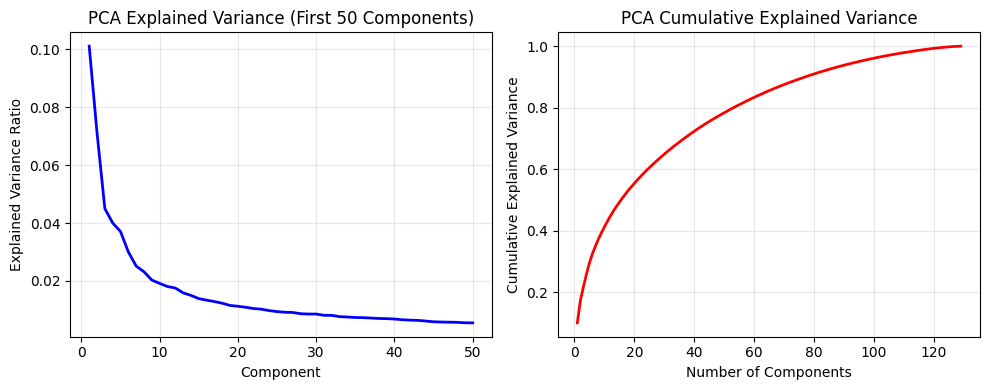

Plotting first two PCA components with metadata coloring...


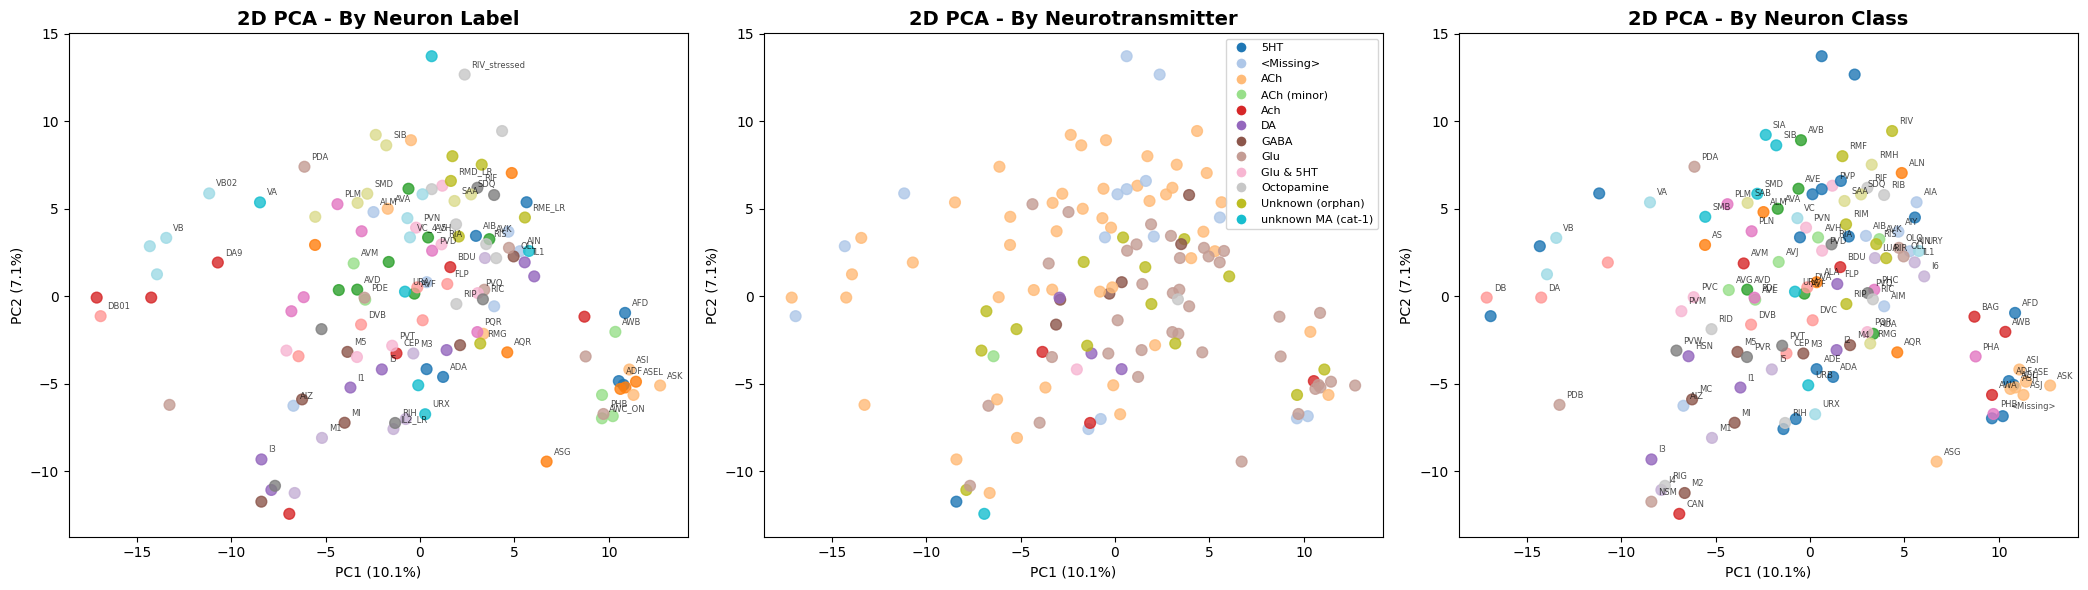

PCA visualization complete
X_pca shape: (130, 129)
Number of neurons: 130
Number of principal components: 129


In [122]:
# PCA Preprocessing for Dimensionality Reduction and Visualization
print("Applying PCA preprocessing to reduce dimensions and visualize data...")
print(f"Original data shape: {X_original.shape}")

# Maximum allowable PCA components is min(n_samples-1, n_features)
max_pca_components = min(N_neurons - 1, X_original.shape[1])
n_pca_components = max_pca_components  # Use maximum to preserve as much variance as possible

print(f"Using {n_pca_components} PCA components (max allowable: {max_pca_components})")

# Fit PCA
pca_preprocess = PCA(n_components=n_pca_components, random_state=41)
X_pca = pca_preprocess.fit_transform(X_original)

print(f"PCA preprocessed data shape: {X_pca.shape}")
print(f"Explained variance ratio (first 10 components): {pca_preprocess.explained_variance_ratio_[:10]}")
print(f"Total explained variance: {pca_preprocess.explained_variance_ratio_.sum():.4f}")

# Plot cumulative explained variance
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, min(50, len(pca_preprocess.explained_variance_ratio_)) + 1), 
         pca_preprocess.explained_variance_ratio_[:50], 'b-', linewidth=2)
plt.xlabel('Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance (First 50 Components)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(pca_preprocess.explained_variance_ratio_) + 1), 
         np.cumsum(pca_preprocess.explained_variance_ratio_), 'r-', linewidth=2)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot first two PCA components for visualization with metadata coloring
print("Plotting first two PCA components with metadata coloring...")

# Create figure with 3 subplots: original coloring, neurotransmitter, cell type
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Prepare metadata color mappings
unique_nt = np.unique(neuron_neurotransmitters)
nt_to_color = {nt: i for i, nt in enumerate(unique_nt)}
unique_cls = np.unique(neuron_classes)
cls_to_color = {cls: i for i, cls in enumerate(unique_cls)}

# Prepare colormaps - use actual colors instead of indices
cmap = plt.cm.tab20
nt_color_values = [cmap(nt_to_color[nt] / len(unique_nt)) for nt in neuron_neurotransmitters]
cls_color_values = [cmap(cls_to_color[cls] / len(unique_cls)) for cls in neuron_classes]

# Plot 1: Original (by neuron index) with annotations for every other neuron
ax = axes[0]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], 
                    c=range(len(neuron_labels)), cmap='tab20', s=60, alpha=0.8)
ax.set_title('2D PCA - By Neuron Label', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_preprocess.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_preprocess.explained_variance_ratio_[1]:.1%})')

# Add text annotations for every other neuron
for i in range(0, len(neuron_labels), 2):
    ax.annotate(neuron_labels[i],
                (X_pca[i, 0], X_pca[i, 1]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=6, alpha=0.7)

# Plot 2: Colored by neurotransmitter
ax = axes[1]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], 
                    c=nt_color_values, s=60, alpha=0.8)  # Use actual colors, not cmap
ax.set_title('2D PCA - By Neurotransmitter', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_preprocess.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_preprocess.explained_variance_ratio_[1]:.1%})')

# Add legend for neurotransmitters
handles = [plt.Line2D([0], [0], marker='o', color='w', 
                     markerfacecolor=cmap(nt_to_color[nt]/len(unique_nt)), 
                     markersize=8, label=nt) for nt in unique_nt]
ax.legend(handles=handles, loc='best', fontsize=8)

# Plot 3: Colored by neuron class with text annotations
ax = axes[2]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], 
                    c=cls_color_values, s=60, alpha=0.8)
ax.set_title('2D PCA - By Neuron Class', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_preprocess.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_preprocess.explained_variance_ratio_[1]:.1%})')

# For each unique class, find one representative point and add text annotation
for cls in unique_cls:
    # Find indices where this class appears
    cls_indices = np.where(neuron_classes == cls)[0]
    if len(cls_indices) > 0:
        # Take the first occurrence as representative
        idx = cls_indices[0]
        # Add text annotation with small offset
        ax.annotate(cls, 
                   (X_pca[idx, 0], X_pca[idx, 1]),
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=6, alpha=0.7)

plt.tight_layout()
plt.show()

print("PCA visualization complete")
print(f"X_pca shape: {X_pca.shape}")
print(f"Number of neurons: {N_neurons}")
print(f"Number of principal components: {X_pca.shape[1]}")


#### **OPTIONAL:** Choose a random subset of features to keep from `X_original` as the data that gets augemented thought `GaussianRandomProjection`.


In [137]:
# Select a higher-dimensional subset of features from X_original for random projection

# This gives us a manageable but still high-dimensional input space
input_dim = X_original.shape[1] - 1 #8192
print(f"Selecting {input_dim} random features from {X_original.shape[1]} total features")

# Randomly select input_dim features without replacement
selected_features = np.random.choice(X_original.shape[1], size=input_dim, replace=False)
selected_features.sort()  # Sort indices for consistency

# Create new X_original with only selected features
X_original = X_original[:, selected_features]
print(f"X_original shape: {X_original.shape}")
# NOTE: Do NOT standardize features (genes) with StandardScaler. It strips away the variance imformation.
print(f"Without standardization {X_original.mean(axis=0).shape} genes (first 5) \n\tmean: {X_original.mean(axis=0)[:5]}, \n\tstd: {X_original.std(axis=0)[:5]}")

print(f"\nData ready for random projection: {X_original.shape}")
print(f"This will be projected to embedding_dim determined by JL lemma")

Selecting 22468 random features from 22469 total features
X_original shape: (130, 22468)
Without standardization (22468,) genes (first 5) 
	mean: [2.87590796 1.01728045 0.8490579  1.07566784 1.96477043], 
	std: [0.92014032 0.41039817 0.42220107 0.57693753 0.81696442]

Data ready for random projection: (130, 22468)
This will be projected to embedding_dim determined by JL lemma


In [124]:
# Calculate minimum dimension needed for JL lemma
n_samples = N_neurons  # We're preserving distances between neurons
epsilon = CONFIG_TRANSCRIPTOMICS['jl_epsilon']
min_dim = johnson_lindenstrauss_min_dim(n_samples=n_samples, eps=epsilon)

print(f"JL minimum dimension for n={n_samples}, eps={epsilon}: {min_dim}")
print(f"Original dimension: {X_original.shape[1]}")

# Use this as our embedding dimension (update CONFIG_TRANSCRIPTOMICS if needed)
embedding_dim = min_dim.item()
print(f"Using embedding_dim = {embedding_dim}")

# Update CONFIG_TRANSCRIPTOMICS with the calculated dimension
print(f"Updating CONFIG_TRANSCRIPTOMICS['embedding_dim'] from {CONFIG_TRANSCRIPTOMICS['embedding_dim']} to {embedding_dim}")
CONFIG_TRANSCRIPTOMICS['embedding_dim'] = embedding_dim

# Create and fit GaussianRandomProjection
grp = GaussianRandomProjection(n_components=embedding_dim, eps=epsilon)
X_projected = grp.fit_transform(X_original)

print(f"\nGaussian Random Projection output shape: {X_projected.shape}")
print(f"Projection matrix shape: {grp.components_.shape}")


JL minimum dimension for n=130, eps=0.3: 540
Original dimension: 22469
Using embedding_dim = 540
Updating CONFIG_TRANSCRIPTOMICS['embedding_dim'] from 512 to 540

Gaussian Random Projection output shape: (130, 540)
Projection matrix shape: (540, 22469)


## Custom Transcriptome Dataset with Johnson-Lindenstrauss Random Projection

Since we have only one (N, D) embedding matrix from the original transcriptome data, we need to generate multiple training samples. Our innovation is to create synthetic but meaningful variations using Johnson-Lindenstrauss random Gaussian projections.

**Key insight**: Each random projection preserves pairwise distances between neurons with high probability (JL lemma guarantee), while creating novel projections. This allows generation of effectively unlimited training samples with theoretically grounded distance preservation.


In [132]:
class TranscriptomeGaussianProjectionDataset(Dataset):
    """
    Dataset that generates synthetic transcriptome embeddings using sklearn GaussianRandomProjection.
    """
    
    def __init__(self, X_original, num_samples, embedding_dim, epsilon, seed=None, precompute=None):
        """
        Args:
            X_original: (N, D_original) numpy array of preprocessed transcriptome data
            num_samples: total number of augmented samples to generate
            embedding_dim: target dimension for random projection
            epsilon: JL epsilon parameter for distance preservation
            seed: base random seed for reproducibility
            precompute: if True, precompute all samples in __init__ for faster training
        """
        # Convert input to torch tensor if needed  
        self.X_original = torch.tensor(X_original, dtype=torch.float32) if isinstance(X_original, np.ndarray) else X_original # (N_neurons, input_dim)
        self.N_neurons, self.input_dim = X_original.shape
        self.num_samples = num_samples
        self.embedding_dim = embedding_dim
        self.epsilon = epsilon
        self.seed = seed
        self.precompute = num_samples <= 100 if precompute is None else precompute
        
        self.N, self.D_original = X_original.shape
        print(f"GaussianProjectionDataset: {self.N} neurons, {self.D_original} → {embedding_dim} dims, {num_samples} samples")
        
        if self.precompute:
            # Precompute all samples once in memory
            start_time = time.time()
            self.samples = []
            
            for idx in range(num_samples):
                sample = self.compute_sample(idx)
                self.samples.append(sample)
            
            end_time = time.time()
            duration = end_time - start_time
            print(f"Precomputed {len(self.samples)} samples in {duration:.2f} seconds ({duration/len(self.samples):.2f} seconds per sample)")
        else:
            # We will compute samples on the fly in __getitem__
            self.samples = None

    def compute_sample(self, idx):
        # Create a GaussianRandomProjection with unique seed for this sample
        if self.seed is not None:
            random_state = self.seed + idx
        else:
            random_state = idx
            
        projector = GaussianRandomProjection(
            n_components=self.embedding_dim,
            eps=self.epsilon,
            random_state=random_state
        )
        
        # Fit and transform the data
        X_projected = projector.fit_transform(self.X_original.numpy())  # (N_neurons, embedding_dim)

        # Convert back to a tensor and move to device
        X_tensor = torch.tensor(X_projected, dtype=torch.float32)
        
        return X_tensor

    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        if self.precompute:
            return self.samples[idx]
        else:
            return self.compute_sample(idx)


# Test the dataset creation
print("Testing the TranscriptomeGaussianProjectionDataset...")
dataset = TranscriptomeGaussianProjectionDataset(
    X_original=X_original,
    num_samples=100,  # Test with smaller number first
    embedding_dim=embedding_dim,
    epsilon=CONFIG_TRANSCRIPTOMICS['jl_epsilon'],
    seed=42,
    precompute=True
)

# Test a few samples
sample = dataset[0]
print(f"\nSample shape: {sample.shape}, dtype: {sample.dtype}")
print(f"Sample mean (first 3 neurons): {sample.mean(dim=-1)[:3]}")
print(f"Sample std (first 3 neurons): {sample.std(dim=-1)[:3]}")

# Test that different samples are different
sample2 = dataset[1]
diff = torch.norm(sample - sample2).item()
print(f"\nDifference between samples 0 and 1: {diff:.3f}")

sampleN = dataset[-1]
diff = torch.norm(sample - sampleN).item()
print(f"Difference between samples 0 and {len(dataset)-1}: {diff:.3f}")

# Create data loader
dataloader = DataLoader(dataset, batch_size=CONFIG_TRANSCRIPTOMICS['batch_size'], shuffle=True)
batch = next(iter(dataloader))
print(f"\nBatch shape: {batch.shape}")
print(f"Batch dtype: {batch.dtype}")

Testing the TranscriptomeGaussianProjectionDataset...
GaussianProjectionDataset: 130 neurons, 22469 → 540 dims, 100 samples
Precomputed 100 samples in 15.17 seconds (0.15 seconds per sample)

Sample shape: torch.Size([130, 540]), dtype: torch.float32
Sample mean (first 3 neurons): tensor([-0.0180, -0.0359,  0.0169])
Sample std (first 3 neurons): tensor([1.3369, 1.2460, 1.2967])

Difference between samples 0 and 1: 491.179
Difference between samples 0 and 99: 492.850

Batch shape: torch.Size([64, 130, 540])
Batch dtype: torch.float32


### Sanity Check: Johnson-Lindenstrauss Distance Preservation

Let's verify that our random projection augmentation preserves pairwise distances between neurons (JL lemma guarantee). We'll compare pairwise distance correlations between different random projections.


Performing sanity check on Johnson-Lindenstrauss distance preservation...
GaussianProjectionDataset: 130 neurons, 22469 → 540 dims, 1 samples
GaussianProjectionDataset: 130 neurons, 22469 → 540 dims, 1 samples

JL Distance Preservation Results:
Original shape: (130, 22469)
Sample 1 shape: (130, 540)
Sample 2 shape: (130, 540)
Correlation between pairwise distances (original vs sample1): 0.9749
Correlation between pairwise distances (original vs sample2): 0.9807
Correlation between pairwise distances (sample1 vs sample2): 0.9532
Expected minimum correlation (1-ε): 0.700
Actual correlation (mean of 3) : 0.970
✓ PASS: JL distance preservation working correctly!


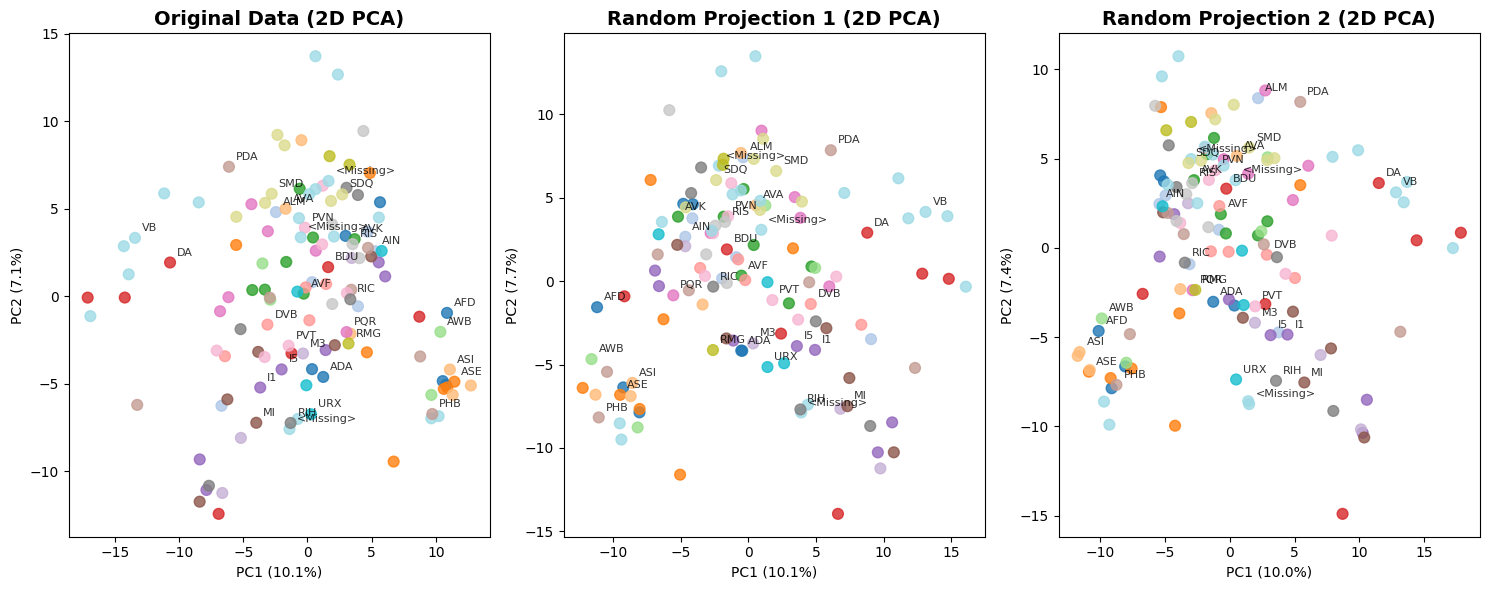

In [133]:
# Sanity check: Test JL distance preservation between random projections
print("Performing sanity check on Johnson-Lindenstrauss distance preservation...")

# Generate two different random projections
test_dataset1 = TranscriptomeGaussianProjectionDataset(
    X_original=X_original,
    num_samples=1,
    embedding_dim=embedding_dim,
    epsilon=CONFIG_TRANSCRIPTOMICS['jl_epsilon'],
    seed=1000,
    precompute=False
)

test_dataset2 = TranscriptomeGaussianProjectionDataset(
    X_original=X_original,
    num_samples=1,
    embedding_dim=embedding_dim,
    epsilon=CONFIG_TRANSCRIPTOMICS['jl_epsilon'],
    seed=2000,
    precompute=False
)

sample0 = X_original # Shape: (N, D_original)
sample1 = test_dataset1[0].numpy()  # Shape: (N, D_embedding)
sample2 = test_dataset2[0].numpy()  # Shape: (N, D_embedding)

# Compute pairwise distances for both projections
distances0 = pdist(X_original)
distances1 = pdist(sample1)
distances2 = pdist(sample2)

# Calculate correlation between distance matrices
correlation_01 = np.corrcoef(distances0, distances1)[0, 1]
correlation_02 = np.corrcoef(distances0, distances2)[0, 1]
correlation_12 = np.corrcoef(distances1, distances2)[0, 1]

print(f"\nJL Distance Preservation Results:")
print(f"Original shape: {X_original.shape}")
print(f"Sample 1 shape: {sample1.shape}")
print(f"Sample 2 shape: {sample2.shape}")
print(f"Correlation between pairwise distances (original vs sample1): {correlation_01:.4f}")
print(f"Correlation between pairwise distances (original vs sample2): {correlation_02:.4f}")
print(f"Correlation between pairwise distances (sample1 vs sample2): {correlation_12:.4f}")

# Get the mean of the 3 pairwise correlations
mean_correlation = (correlation_01 + correlation_02 + correlation_12) / 3

# Test JL lemma bounds
# JL lemma: (1-ε)||x-y||² ≤ ||Px-Py||² ≤ (1+ε)||x-y||²
# So correlation should be high (close to 1) for good distance preservation
epsilon = CONFIG_TRANSCRIPTOMICS['jl_epsilon']
expected_min_correlation = 1 - epsilon  # Rough approximation

print(f"Expected minimum correlation (1-ε): {expected_min_correlation:.3f}")
print(f"Actual correlation (mean of 3) : {mean_correlation:.3f}")

if mean_correlation > expected_min_correlation:
    print("✓ PASS: JL distance preservation working correctly!")
else:
    print("⚠ WARNING: Distance preservation may not meet JL bounds")

# Visualize with 2D PCA for both samples
pca1_2d = PCA(n_components=2, random_state=42)
pca2_2d = PCA(n_components=2, random_state=43)

# Fit PCA on first sample and transform both
sample1_pca = pca1_2d.fit_transform(sample1)
sample2_pca = pca2_2d.fit_transform(sample2)

# Create comparison plot
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(15, 6))

# Create a consistent color mapping for neurons
unique_colors = plt.cm.tab20(np.linspace(0, 1, len(neuron_classes)))
color_dict = dict(zip(neuron_classes, unique_colors))
colors = [color_dict[neuron] for neuron in neuron_classes]

# Plot original 
scatter0 = ax0.scatter(X_pca[:, 0], X_pca[:, 1], 
                      c=colors, s=60, alpha=0.8)
ax0.set_title('Original Data (2D PCA)', fontsize=14, fontweight='bold')
ax0.set_xlabel(f'PC1 ({pca_preprocess.explained_variance_ratio_[0]:.1%})')
ax0.set_ylabel(f'PC2 ({pca_preprocess.explained_variance_ratio_[1]:.1%})')

# Plot sample 1
scatter1 = ax1.scatter(sample1_pca[:, 0], sample1_pca[:, 1], 
                      c=colors, s=60, alpha=0.8)
ax1.set_title('Random Projection 1 (2D PCA)', fontsize=14, fontweight='bold')
ax1.set_xlabel(f'PC1 ({pca1_2d.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'PC2 ({pca1_2d.explained_variance_ratio_[1]:.1%})')

# Plot sample 2
scatter2 = ax2.scatter(sample2_pca[:, 0], sample2_pca[:, 1], 
                      c=colors, s=60, alpha=0.8)
ax2.set_title('Random Projection 2 (2D PCA)', fontsize=14, fontweight='bold')
ax2.set_xlabel(f'PC1 ({pca2_2d.explained_variance_ratio_[0]:.1%})')
ax2.set_ylabel(f'PC2 ({pca2_2d.explained_variance_ratio_[1]:.1%})')

# Annotate a few points for reference
for i in range(0, len(neuron_classes), 4):  # Annotate every 4th neuron
    ax0.annotate(neuron_classes[i], (X_pca[i, 0], X_pca[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)
    ax1.annotate(neuron_classes[i], (sample1_pca[i, 0], sample1_pca[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)
    ax2.annotate(neuron_classes[i], (sample2_pca[i, 0], sample2_pca[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)

plt.tight_layout()
plt.show()


### Custom Transcriptome Dataset with Random Feature Selection

A simpler and potentially more interpretable approach than random projections is selecting subsets of genes, we're essentially doing feature subsampling, which is a common technique in machine learning. 

This approach has several advantages:
- **Interpretability:** We can see which genes are being used in each sample
- **Simplicity:** No need for JL projections - just random feature selection
- **Biological relevance:** Each sample represents a different "view" of the transcriptome using different gene sets
- **Computational efficiency:** Much faster than random projections


In [134]:
class TranscriptomeFeatureSubsetDataset(Dataset):
    """
    Dataset that generates augmented embeddings by randomly selecting subsets of features (genes).
    Each sample uses a different random subset of embedding_dim features from the original data.
    
    This approach is simpler than random projections and more interpretable - we can see
    which genes are being used in each sample.
    """
    
    def __init__(self, X_original, num_samples, embedding_dim, seed=None, precompute=None):
        """
        Args:
            X_original: (N_neurons, input_dim) numpy array of preprocessed transcriptome data
            num_samples: total number of augmented samples to generate
            embedding_dim: number of features to randomly select for each sample
            seed: base random seed for reproducibility
            precompute: if True, precompute all samples in __init__ for faster training
        """
        # Convert input to tensor if needed
        self.X_original = torch.tensor(X_original, dtype=torch.float32) if isinstance(X_original, np.ndarray) else X_original
        self.N_neurons, self.input_dim = self.X_original.shape
        self.num_samples = num_samples
        self.embedding_dim = embedding_dim
        self.seed = seed
        self.precompute = num_samples <= 100 if precompute is None else precompute
        
        # Validate that we have enough features
        if embedding_dim > self.input_dim:
            raise ValueError(f"embedding_dim ({embedding_dim}) cannot be larger than number of features ({self.input_dim})")
        
        print(f"FeatureSubsetDataset: {self.N_neurons} neurons, {self.input_dim} features → {embedding_dim} features per sample, {num_samples} samples")
        
        if self.precompute:
            # Precompute all samples once in memory
            start_time = time.time()
            self.samples = []
            self.selected_features = []  # Store which features were selected for each sample
            
            for idx in range(num_samples):
                sample, selected_features = self.compute_sample(idx)
                self.samples.append(sample)
                self.selected_features.append(selected_features)
            
            end_time = time.time()
            duration = end_time - start_time
            print(f"Precomputed {len(self.samples)} samples in {duration:.2f} seconds ({duration/len(self.samples):.2f} seconds per sample)")
        else:
            # We will compute samples on the fly in __getitem__
            self.samples = None
            self.selected_features = None

    def compute_sample(self, idx):
        """
        Generate a sample by randomly selecting embedding_dim features.
        
        Returns:
            sample: torch tensor of shape (N_neurons, embedding_dim)
            selected_features: list of feature indices that were selected
        """
        # Set random seed for this sample
        if self.seed is not None:
            torch.manual_seed(self.seed + idx)
        else:
            torch.manual_seed(idx)
        
        # Randomly select embedding_dim features (without replacement)
        selected_features = torch.randperm(self.input_dim)[:self.embedding_dim]
        selected_features, _ = torch.sort(selected_features)  # Sort for consistency
        
        # Extract the selected genes for all neurons
        X_subset = self.X_original[:, selected_features]  # (N_neurons, embedding_dim)
        
        return X_subset, selected_features.tolist()

    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        if self.precompute:
            return self.samples[idx]
        else:
            sample, _ = self.compute_sample(idx)
            return sample
    
    def get_selected_features(self, idx):
        """
        Get the gene indices that were selected for a given sample.
        Only works if precompute=True.
        """
        if not self.precompute:
            raise ValueError("get_selected_features only works when precompute=True")
        return self.selected_features[idx]
    

In [135]:
# Test the new FeatureSubsetDataset
print("Testing the TranscriptomeFeatureSubsetDataset...")
feature_subset_dataset = TranscriptomeFeatureSubsetDataset(
    X_original=X_original,
    num_samples=100,  # Test with smaller number first
    embedding_dim=embedding_dim,
    seed=42,
    precompute=True
)

# Test a few samples
sample = feature_subset_dataset[0]
print(f"\nSample shape: {sample.shape}, dtype: {sample.dtype}")
print(f"Sample mean (first 3 neurons): {sample.mean(dim=-1)[:3]}")
print(f"Sample std (first 3 neurons): {sample.std(dim=-1)[:3]}")

# Test that different samples are different
sample2 = feature_subset_dataset[1]
diff = torch.norm(sample - sample2).item()
print(f"\nDifference between samples 0 and 1: {diff:.3f}")

# Check which features were selected for each sample
selected_features_0 = feature_subset_dataset.get_selected_features(0)
selected_features_1 = feature_subset_dataset.get_selected_features(1)
print(f"\nSample 0 selected features (first 10): {selected_features_0[:10]}")
print(f"Sample 1 selected features (first 10): {selected_features_1[:10]}")
print(f"Overlap between samples 0 and 1: {len(set(selected_features_0) & set(selected_features_1))} features")

# Create data loader
feature_subset_dataloader = DataLoader(feature_subset_dataset, batch_size=CONFIG_TRANSCRIPTOMICS['batch_size'], shuffle=True)
batch = next(iter(feature_subset_dataloader))
print(f"\nBatch shape: {batch.shape}")
print(f"Batch dtype: {batch.dtype}")


Testing the TranscriptomeFeatureSubsetDataset...
FeatureSubsetDataset: 130 neurons, 22469 features → 540 features per sample, 100 samples
Precomputed 100 samples in 0.04 seconds (0.00 seconds per sample)

Sample shape: torch.Size([130, 540]), dtype: torch.float32
Sample mean (first 3 neurons): tensor([0.0433, 0.0378, 0.0493])
Sample std (first 3 neurons): tensor([0.2237, 0.2048, 0.1851])

Difference between samples 0 and 1: 78.753

Sample 0 selected features (first 10): [138, 164, 175, 244, 299, 314, 374, 400, 440, 448]
Sample 1 selected features (first 10): [10, 44, 148, 208, 217, 229, 239, 289, 298, 422]
Overlap between samples 0 and 1: 5 features

Batch shape: torch.Size([64, 130, 540])
Batch dtype: torch.float32


In [136]:
# Compare Feature Subset vs Random Projection approaches
print("="*80)
print("COMPARING FEATURE SUBSET vs RANDOM PROJECTION APPROACHES")
print("="*80)

# Create both datasets with same parameters
test_samples = 50
test_embedding_dim = 512

print(f"Creating test datasets with {test_samples} samples, {test_embedding_dim} dimensions...")

# Random Projection Dataset
rp_dataset = TranscriptomeGaussianProjectionDataset(
    X_original=X_original,
    num_samples=test_samples,
    embedding_dim=test_embedding_dim,
    epsilon=CONFIG_TRANSCRIPTOMICS['jl_epsilon'],
    seed=42,
    precompute=True
)

# Feature Subset Dataset
fs_dataset = TranscriptomeFeatureSubsetDataset(
    X_original=X_original,
    num_samples=test_samples,
    embedding_dim=test_embedding_dim,
    seed=42,
    precompute=True
)

print(f"\nDataset comparison:")
print(f"  Random Projection: {rp_dataset.__class__.__name__}")
print(f"  Feature Subset: {fs_dataset.__class__.__name__}")

# Compare sample properties
rp_sample = rp_dataset[0]
fs_sample = fs_dataset[0]

print(f"\nSample properties:")
print(f"  Random Projection - Shape: {rp_sample.shape}, Mean: {rp_sample.mean():.4f}, Std: {rp_sample.std():.4f}")
print(f"  Feature Subset - Shape: {fs_sample.shape}, Mean: {fs_sample.mean():.4f}, Std: {fs_sample.std():.4f}")

# Compare pairwise distances preservation
print(f"\nDistance preservation analysis:")

# Get a few samples from each dataset
rp_samples = [rp_dataset[i].numpy() for i in range(5)]
fs_samples = [fs_dataset[i].numpy() for i in range(5)]

# Calculate pairwise distance correlations
rp_correlations = []
fs_correlations = []

for i in range(5):
    # Random projection correlations
    rp_dist = pdist(rp_samples[i])
    rp_corr = np.corrcoef(pdist(X_original), rp_dist)[0, 1]
    rp_correlations.append(rp_corr)
    
    # Feature subset correlations
    fs_dist = pdist(fs_samples[i])
    fs_corr = np.corrcoef(pdist(X_original), fs_dist)[0, 1]
    fs_correlations.append(fs_corr)

print(f"  Random Projection distance correlations: {np.mean(rp_correlations):.4f} ± {np.std(rp_correlations):.4f}")
print(f"  Feature Subset distance correlations: {np.mean(fs_correlations):.4f} ± {np.std(fs_correlations):.4f}")


COMPARING FEATURE SUBSET vs RANDOM PROJECTION APPROACHES
Creating test datasets with 50 samples, 512 dimensions...
GaussianProjectionDataset: 130 neurons, 22469 → 512 dims, 50 samples
Precomputed 50 samples in 7.27 seconds (0.15 seconds per sample)
FeatureSubsetDataset: 130 neurons, 22469 features → 512 features per sample, 50 samples
Precomputed 50 samples in 0.02 seconds (0.00 seconds per sample)

Dataset comparison:
  Random Projection: TranscriptomeGaussianProjectionDataset
  Feature Subset: TranscriptomeFeatureSubsetDataset

Sample properties:
  Random Projection - Shape: torch.Size([130, 512]), Mean: 0.0205, Std: 1.3538
  Feature Subset - Shape: torch.Size([130, 512]), Mean: 0.0471, Std: 0.2114

Distance preservation analysis:
  Random Projection distance correlations: 0.9765 ± 0.0016
  Feature Subset distance correlations: 0.4875 ± 0.0581


In [ ]:
# Configuration for choosing between dataset approaches
print("="*80)
print("DATASET APPROACH CONFIGURATION")
print("="*80)

print(f"Current dataset type: {CONFIG_TRANSCRIPTOMICS['dataset_type']}")

def create_transcriptome_dataset(X_original, num_samples, embedding_dim, config, seed=None, precompute=None):
    """
    Factory function to create the appropriate transcriptome dataset based on config.
    
    Args:
        X_original: (N_neurons, N_genes) numpy array
        num_samples: number of samples to generate
        embedding_dim: target embedding dimension
        config: configuration dictionary
        seed: random seed
        precompute: whether to precompute samples
    
    Returns:
        Dataset object (either TranscriptomeGaussianProjectionDataset or TranscriptomeFeatureSubsetDataset)
    """
    dataset_type = config.get('dataset_type', 'feature_subset')
    
    if dataset_type == 'random_projection':
        return TranscriptomeGaussianProjectionDataset(
            X_original=X_original,
            num_samples=num_samples,
            embedding_dim=embedding_dim,
            epsilon=config.get('jl_epsilon', 0.1),
            seed=seed,
            precompute=precompute
        )
    elif dataset_type == 'feature_subset':
        return TranscriptomeFeatureSubsetDataset(
            X_original=X_original,
            num_samples=num_samples,
            embedding_dim=embedding_dim,
            seed=seed,
            precompute=precompute
        )
    else:
        raise ValueError(f"Unknown dataset_type: {dataset_type}. Must be 'random_projection' or 'feature_subset'")

# Test the factory function
print(f"\nTesting dataset factory function...")
test_dataset = create_transcriptome_dataset(
    X_original=X_original,
    num_samples=10,
    embedding_dim=128,
    config=CONFIG_TRANSCRIPTOMICS,
    seed=42,
    precompute=True
)

print(f"Created dataset: {test_dataset.__class__.__name__}")
print(f"Dataset shape: {test_dataset[0].shape}")


DATASET APPROACH CONFIGURATION
Current dataset type: feature_subset

Testing dataset factory function...
FeatureSubsetDataset: 130 neurons, 22469 features → 128 features per sample, 10 samples
Precomputed 10 samples in 0.01 seconds (0.00 seconds per sample)
Created dataset: TranscriptomeFeatureSubsetDataset
Dataset shape: torch.Size([130, 128])

To switch between approaches, modify CONFIG_TRANSCRIPTOMICS['dataset_type']:
  CONFIG_TRANSCRIPTOMICS['dataset_type'] = 'random_projection'  # For JL projections
  CONFIG_TRANSCRIPTOMICS['dataset_type'] = 'feature_subset'     # For gene subset selection

Current configuration:
  embedding_dim: 540
  hidden_dim: 1024
  batch_size: 64
  learning_rate: 0.001
  num_samples: 12800
  jl_epsilon: 0.3
  use_attention_scores: False
  consistency_weight: 0.0
  consistency_type: variance
  dataset_type: feature_subset


## Attention Model Architecture with Random Dropout Masking

We implement the `SingleHeadSelfAttention` module that learns to reconstruct each neuron's embedding using only the embeddings of other neurons. The key innovations are:
1. Diagonal masking that prevents self-attention
2. Random dropout masking during training that forces robust attention patterns

**Architecture**:
- Input: (batch, N, D) tensor of neuron embeddings
- Output: reconstructed embeddings and attention weights
- Diagonal mask: A[i,i] = 0 (prevent self-attention)
- Random dropout mask: During training, randomly mask 1 additional neuron per row to prevent overfitting


### The Decoder part of the Transformer Architecture

![Decoder Architecture](figures/transformer_decoder.png)


In [13]:
# TODO: Encapsulate a custom decoder layer into a class. 
# We may want to use a deep Transformer that stacks multiple Attention (and MLP) layers.

## Mistral example of how to implement a decoder layer
# class MistralDecoderLayer(GradientCheckpointingLayer):
#     def __init__(self, config: MistralConfig, layer_idx: int):
#         super().__init__()
#         self.hidden_size = config.hidden_size
#         self.self_attn = MistralAttention(config=config, layer_idx=layer_idx)
#         self.mlp = MistralMLP(config)
#         self.input_layernorm = MistralRMSNorm(config.hidden_size, eps=config.rms_norm_eps)
#         self.post_attention_layernorm = MistralRMSNorm(config.hidden_size, eps=config.rms_norm_eps)

#     @deprecate_kwarg("past_key_value", new_name="past_key_values", version="4.58")
#     def forward(
#         self,
#         hidden_states: torch.Tensor,
#         attention_mask: Optional[torch.Tensor] = None,
#         position_ids: Optional[torch.LongTensor] = None,
#         past_key_values: Optional[Cache] = None,
#         use_cache: Optional[bool] = False,
#         cache_position: Optional[torch.LongTensor] = None,
#         position_embeddings: Optional[tuple[torch.Tensor, torch.Tensor]] = None,  # necessary, but kept here for BC
#         **kwargs: Unpack[TransformersKwargs],
#     ) -> torch.Tensor:
#         residual = hidden_states
#         hidden_states = self.input_layernorm(hidden_states)
#         # Self Attention
#         hidden_states, _ = self.self_attn(
#             hidden_states=hidden_states,
#             attention_mask=attention_mask,
#             position_ids=position_ids,
#             past_key_values=past_key_values,
#             use_cache=use_cache,
#             cache_position=cache_position,
#             position_embeddings=position_embeddings,
#             **kwargs,
#         )
#         hidden_states = residual + hidden_states

#         # Fully Connected
#         residual = hidden_states
#         hidden_states = self.post_attention_layernorm(hidden_states)
#         hidden_states = self.mlp(hidden_states)
#         hidden_states = residual + hidden_states
#         return hidden_states

In [14]:
# TODO: Figure out how to implement multi-head self-attention
class SingleHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_hidden, use_attention_scores=False, verbose_timing=False):
        """
        A single head of self-attention that projects input tokens to queries, keys and values.
        The value projection implements an identity function (i.e. the values `V` will equal the input `x`) 
        so no output projection needed.
        
        Args:
            d_model: the dimension of the input tokens (D)
            n_hidden: the hidden dimension for Q/K projections
            use_attention_scores: if True, use raw attention scores instead of softmax weights
            verbose_timing: if True, print timing information for each step
        """
        super().__init__()
        # Q, K, and V projections
        self.W_Q = nn.Linear(d_model, n_hidden, bias=False)  # Query projection
        self.W_K = nn.Linear(d_model, n_hidden, bias=False)  # Key projection
        self.W_V = nn.Identity()  # Value projection; Using Identity means values = inputs
        # NOTE: If we were to use multiple heads: 
        # W_Q and W_K would be torch.nn.Linear(d_model, n_hidden*num_heads, bias=False)
        # W_V would be num_heads Identity matrices vertically stacked 
        #     i.e. matrix shape (output_dim, input_dim) = (num_heads*d_model, d_model)
        #     id = torch.eye(d_model); param = torch.nn.Parameter( torch.concat( num_heads * (id, ) ), requires_grad=False )
        #     W_V = torch.nn.Linear(d_model, num_heads*d_model, bias=False); W_V.weight = param; 
        #     Just to make sure: [ param.requires_grad_(False) for param in W_V.parameters() ]
        self.d_model = d_model
        self.n_hidden = n_hidden
        self.use_attention_scores = use_attention_scores
        self.verbose_timing = verbose_timing

    def forward(self, x, attn_mask=None, mask_other=False):
        """
        NOTE: Tokens in are the same shape as the tokens out (batch, n_neurons, d_model).
        Args:
            x: input token tensor (i.e. embeddings) of shape (batch, n_neurons, d_model)
            attn_mask: optional mask tensor of shape (batch, n_neurons, n_neurons); defaults to diagonal 'self' mask.
            mask_other: if True, radnomly mask out one additional random neuron (besides self) per row of the attention matrix

        Returns:
            reconstructed: reconstructed embeddings of shape (batch, n_neurons, d_model)
            attn_weights: attention weights of shape (batch, n_neurons, n_neurons)
            attn_scores: attention scores of shape (batch, n_neurons, n_neurons)
        """
        start_time = time.time()
        batch_size, n_neurons, d_model = x.shape
        device = x.device

        # Compute Q, K, V projections
        Q = self.W_Q(x)  # (batch, n_neurons, n_hidden)
        K = self.W_K(x)  # (batch, n_neurons, n_hidden)
        V = self.W_V(x)  # (batch, n_neurons, d_model)
        # # NOTE: If we were to use multiple heads:
        # Q = self.W_Q(x).view((batch, n_neurons, -1, self.n_hidden)).transpose(1, 2) # (batch, num_heads, n_neurons, n_hidden)
        # K = self.W_K(x).view((batch, n_neurons, -1, self.n_hidden)).transpose(1, 2) # (batch, num_heads, n_neurons, n_hidden)
        # V = self.W_V(x).view((batch, n_neurons, -1, self.d_model)).transpose(1, 2) # (batch, num_heads, n_neurons, d_model)
        print(f"QK/V projections done in {time.time() - start_time:.3f}s") if self.verbose_timing else None

        # Create base diagonal mask (1 everywhere except diagonal)
        mask_time = time.time()
        if attn_mask is None:
            attn_mask = (1 - torch.eye(n_neurons, device=device)).unsqueeze(0).expand(batch_size, -1, -1)
        
        # During training, mask one additional random neuron per row
        if mask_other: # NOTE: This will be significantly slower than the diagonal masking
            # Clone mask to avoid modifying the original
            attn_mask = attn_mask.clone()
            
            # For each sample in batch, for each neuron (row), randomly mask 1 additional non-self neuron
            # TODO: Parallelize this so we don't have a double for loop
            for b in range(batch_size):
                for i in range(n_neurons):
                    # Get indices of non-self neurons (where mask is currently 1)
                    non_self_indices = torch.where(attn_mask[b, i, :] == 1)[0]
                    
                    # Randomly select 1 index to mask out
                    if len(non_self_indices) > 0:
                        rand_idx = torch.randint(0, len(non_self_indices), (1,), device=device)
                        neuron_to_mask = non_self_indices[rand_idx]
                        attn_mask[b, i, neuron_to_mask] = 0
        
        print(f"Attention masking done in {time.time() - mask_time:.3f}s") if self.verbose_timing else None

        # Compute attention
        attn_time = time.time()
        # Compute scaled dot-product attention scores
        scores = torch.bmm(Q, K.transpose(1, 2)) / (self.n_hidden**0.5)
        
        # Apply mask by setting masked positions to -inf
        inf_masked_scores = scores.masked_fill(attn_mask == 0, float("-inf"))

        # Compute masked attention weights
        attn_weights = torch.softmax(inf_masked_scores, dim=-1)

        # We want masked scores but with 0s instead of -infs for visualization
        attn_scores = scores.masked_fill(attn_mask == 0, 0.0)
        print(f"Attention computation done in {time.time() - attn_time:.3f}s") if self.verbose_timing else None

        # Apply attention to values
        recon_time = time.time()
        if self.use_attention_scores:
            reconstructed = torch.bmm(attn_scores, V)
        else:
            reconstructed = torch.bmm(attn_weights, V)
        print(f"Reconstruction done in {time.time() - recon_time:.3f}s") if self.verbose_timing else None
        print(f"Total forward pass time: {time.time() - start_time:.3f}s") if self.verbose_timing else None

        return reconstructed, attn_weights, attn_scores


In [15]:
# Test the attention model
print("Testing SingleHeadSelfAttention model...")
print(f"Using device: {device}")

# Create model for transcriptomics
model_transcriptomics = SingleHeadSelfAttention(
    d_model=CONFIG_TRANSCRIPTOMICS['embedding_dim'],
    n_hidden=CONFIG_TRANSCRIPTOMICS['hidden_dim'],
    use_attention_scores=CONFIG_TRANSCRIPTOMICS['use_attention_scores']
).to(device)

print(f"Model created with {sum(p.numel() for p in model_transcriptomics.parameters())} parameters")

Testing SingleHeadSelfAttention model...
Using device: mps
Model created with 1103872 parameters


In [16]:
# Test with a batch
test_batch = batch.to(device)  # (batch_size, n_neurons, d_model)
print(f"Test batch shape: {test_batch.shape}")

# Test with additional masking of one other neuron per row
model_transcriptomics.train()
with torch.no_grad():
    start_time = time.time()
    reconstructed_other, attn_weights_other, attn_scores_other = model_transcriptomics(test_batch, mask_other=True)
    print(f"Masking other mode done in {time.time() - start_time:.3f}s")

print(f"Masking other mode - Reconstructed shape: {reconstructed_other.shape}")
print(f"Masking other mode - Attention weights shape: {attn_weights_other.shape}")
print(f"Masking other mode - Attention scores shape: {attn_scores_other.shape}")

# Check that diagonal is zero in attention weights
diagonal_weights_other = torch.diagonal(attn_weights_other[0], dim1=0, dim2=1)
print(f"Diagonal attention weights (should be ~0): {diagonal_weights_other[:5]}")

# Check reconstruction error
reconstruction_error_other = torch.norm(test_batch - reconstructed_other, dim=-1).mean()
print(f"Initial reconstruction error (masking other mode): {reconstruction_error_other:.3f}")

# Test regular mode where just the diagonal (self-reference) is masked
model_transcriptomics.eval()
with torch.no_grad():
    start_time = time.time()
    reconstructed_regular, attn_weights_regular, attn_scores_regular = model_transcriptomics(test_batch, mask_other=False)
    print(f"Diagonal masking mode done in {time.time() - start_time:.3f}s")

print()
print(f"Diagonal masking mode - Reconstructed shape: {reconstructed_regular.shape}")
print(f"Diagonal masking mode - Attention weights shape: {attn_weights_regular.shape}")

# Check that diagonal is zero in attention weights
diagonal_weights_regular = torch.diagonal(attn_weights_regular[0], dim1=0, dim2=1)
print(f"Diagonal attention weights (should be ~0): {diagonal_weights_regular[:5]}")

# Check reconstruction error
reconstruction_error_regular = torch.norm(test_batch - reconstructed_regular, dim=-1).mean()
print(f"Initial reconstruction error (diagonal masking mode): {reconstruction_error_regular:.3f}")

# Check that diagonal masking and random masking modes produce different results 
diff = torch.norm(attn_weights_other - attn_weights_regular).item()
print(f"\nDifference between regular and other attention weights: {diff:.3f}")
if diff > 0.01:
    print("✓ Random dropout masking is working - training and eval modes differ")
else:
    print("⚠ Random dropout masking may not be working properly")


Test batch shape: torch.Size([64, 128, 539])
Masking other mode done in 9.933s
Masking other mode - Reconstructed shape: torch.Size([64, 128, 539])
Masking other mode - Attention weights shape: torch.Size([64, 128, 128])
Masking other mode - Attention scores shape: torch.Size([64, 128, 128])
Diagonal attention weights (should be ~0): tensor([0., 0., 0., 0., 0.], device='mps:0')
Initial reconstruction error (masking other mode): 207.349
Diagonal masking mode done in 0.001s

Diagonal masking mode - Reconstructed shape: torch.Size([64, 128, 539])
Diagonal masking mode - Attention weights shape: torch.Size([64, 128, 128])
Diagonal attention weights (should be ~0): tensor([0., 0., 0., 0., 0.], device='mps:0')
Initial reconstruction error (diagonal masking mode): 207.374

Difference between regular and other attention weights: 9.648
✓ Random dropout masking is working - training and eval modes differ


## 6. Training Loop with Reconstruction Loss and Train/Val Split

We train the attention model to minimize the reconstruction error between original and reconstructed embeddings. The key insight is that the model must learn to combine information from other neurons to reconstruct each neuron's embedding, with the learned attention weights representing the "connectome".

We now use proper train/validation split with different random projections for each set.


#### Batch Consistency Regularization

We implement a batch consistency regularization to encourage similar attention matrices across samples in the batch because in our task each batch is just a collection of views (projections) of the same underlying trasncriptome data. 

In [17]:
# Batch Consistency Loss Functions
def batch_consistency_loss_frobenius(attn_matrices, weight=1.0, reduction='mean'):
    """
    Minimize pairwise Frobenius norms between attention matrices in batch.
    Uses pdist for efficient computation of all pairwise distances.
    
    Args:
        attn_matrices: (B, N, N) tensor
        weight: scalar weight for the loss
        reduction: 'mean' or 'sum'
    
    Returns:
        scalar loss: mean or sum of pairwise Frobenius norms
    """
    B, N, _ = attn_matrices.shape
    
    # Flatten each matrix: (B, N*N)
    flat = attn_matrices.view(B, -1)
    
    # Compute pairwise Euclidean distances (equivalent to Frobenius norms)
    if device.type == 'mps':
        # NOTE: 'aten::_pdist_forward' is not currently implemented for the MPS device so we move tensor to CPU
        pairwise_distances = nn.functional.pdist(flat.cpu(), p=2) # Does this affect the gradients?
    else:
        pairwise_distances = nn.functional.pdist(flat, p=2)
    
    if reduction == 'mean':
        return weight * pairwise_distances.mean()
    elif reduction == 'sum':
        return weight * pairwise_distances.sum()
    else:
        raise ValueError(f"reduction must be 'mean' or 'sum', got {reduction}")

    # # >>>>
    # # Compute pairwise Euclidean distances (equivalent to Frobenius norms)
    # # NOTE: 'aten::_pdist_forward' is not currently implemented for the MPS device
    # if device.type == 'mps':  # Manual pairwise distance computation 
    #     # For each pair (i,j) where i < j, compute ||flat[i] - flat[j]||_2
    #     total_distance = 0.0
    #     pair_count = 0
    #     for i in range(B):
    #         for j in range(i + 1, B):  # Only upper triangular pairs
    #             diff = flat[i] - flat[j]  # (N*N,)
    #             distance = torch.norm(diff, p=2)  # L2 norm = Frobenius norm
    #             total_distance += distance
    #             pair_count += 1
    #     if pair_count == 0:
    #         return torch.tensor(0.0, device=attn_matrices.device)
    #     if reduction == 'mean':
    #         return weight * (total_distance / pair_count)
    #     elif reduction == 'sum':
    #         return weight * total_distance
    #     else:
    #         raise ValueError(f"reduction must be 'mean' or 'sum', got {reduction}")
    # else: # Otherwise, use the default PyTorch implementation
    #     pairwise_distances = nn.functional.pdist(flat, p=2)
    #     if reduction == 'mean':
    #         return weight * pairwise_distances.mean()
    #     elif reduction == 'sum':
    #         return weight * pairwise_distances.sum()
    #     else:
    #         raise ValueError(f"reduction must be 'mean' or 'sum', got {reduction}")
    # # <<<<
    
def batch_consistency_loss_variance(attn_matrices, weight=1.0, reduction='mean'):
    """
    Compute variance across batch dimension to encourage consistency.
    This is the recommended/default approach.
    
    Args:
        attn_matrices: (B, N, N) tensor of attention weights or scores
        reduction: 'mean' or 'sum'
    
    Returns:
        scalar loss: variance across batch dimension, averaged over all (i,j) pairs
    """
    # Compute variance across batch dimension for each (i,j) position
    # var(dim=0) gives (N, N) tensor of variances
    batch_variance = torch.var(attn_matrices, dim=0, unbiased=False)  # (N, N)
    
    if reduction == 'mean':
        return weight * batch_variance.mean()  # Average variance across all positions
    elif reduction == 'sum':
        return weight * batch_variance.sum()
    else:
        raise ValueError(f"reduction must be 'mean' or 'sum', got {reduction}")

print("Batch consistency loss functions defined:")
print("  - batch_consistency_loss_frobenius (pairwise Frobenius norms)")
print("  - batch_consistency_loss_variance (alternative, works well)")


Batch consistency loss functions defined:
  - batch_consistency_loss_frobenius (pairwise Frobenius norms)
  - batch_consistency_loss_variance (alternative, works well)


In [18]:
# Set up training for transcriptomics
criterion = nn.L1Loss() #nn.MSELoss()
optimizer = optim.Adam(model_transcriptomics.parameters(), lr=CONFIG_TRANSCRIPTOMICS['learning_rate'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=100)

# Set the total train and val samples
n_train_samples = CONFIG_TRANSCRIPTOMICS['num_samples']  
n_val_samples = CONFIG_TRANSCRIPTOMICS['batch_size'] # Single batch validation
print(f"Creating datasets: {n_train_samples} train, {n_val_samples} val")

# Create datasets
print("Creating training and validation datasets...")
train_dataset_transcriptomics = TranscriptomeGaussianProjectionDataset(
    X_original=X_original,
    num_samples=n_train_samples,
    embedding_dim=embedding_dim,
    epsilon=CONFIG_TRANSCRIPTOMICS['jl_epsilon'],
    seed=42,
    precompute=False
)

val_dataset_transcriptomics = TranscriptomeGaussianProjectionDataset(
    X_original=X_original,
    num_samples=n_val_samples,
    embedding_dim=embedding_dim,
    epsilon=CONFIG_TRANSCRIPTOMICS['jl_epsilon'],
    seed=42 + n_train_samples,  # Different seed for validation
    precompute=True
)


Creating datasets: 12800 train, 64 val
Creating training and validation datasets...
Dataset: 128 neurons, 127 → 539 dims, 12800 samples
Dataset: 128 neurons, 127 → 539 dims, 64 samples
Precomputed 64 samples in 0.12 seconds (0.00 seconds per sample)


In [19]:
# Fix: Update refactored training function to use partial method
def train_attention_model(model, train_dataset, val_dataset, config, device):
    """
    Updated training function using partial method approach.
    """
    # Set up training
    criterion = nn.L1Loss()
    optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=50)
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False)
    
    # Set up consistency loss function using partial method
    consistency_type = config['consistency_type']
    consistency_weight = config['consistency_weight']
    
    if consistency_type == 'frobenius':
        batch_consistency_loss_fn = partial(batch_consistency_loss_frobenius, weight=consistency_weight, reduction='mean')
    elif consistency_type == 'variance':
        batch_consistency_loss_fn = partial(batch_consistency_loss_variance, weight=consistency_weight, reduction='mean')
    else:
        raise ValueError(f"Unknown consistency_type: {consistency_type}")
    
    if consistency_weight == 0:
        batch_consistency_loss_fn = lambda x: torch.tensor(0.0, device=x.device)
    
    # Track losses
    history = {
        'train_losses': [],
        'train_recon_losses': [],
        'train_consistency_losses': [],
        'val_losses': [],
        'batch_numbers': []
    }
    
    # Training loop
    total_batches = 0
    for batch_idx, train_batch in enumerate(train_loader):
        total_batches += 1
        train_batch = train_batch.to(device)
        
        # Forward pass
        model.train()
        train_reconstructed, train_attn_weights, train_attn_scores = model(train_batch, mask_other=False)
        
        # Reconstruction loss
        recon_loss = criterion(train_reconstructed, train_batch)
        
        # Batch consistency loss using partial function
        consistency_loss = batch_consistency_loss_fn(train_attn_weights)
        
        train_loss = recon_loss + consistency_loss
        
        # Backward pass
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
        
        # Track losses
        history['train_losses'].append(train_loss.item())
        history['train_recon_losses'].append(recon_loss.item())
        history['train_consistency_losses'].append(consistency_loss.item())
        history['batch_numbers'].append(total_batches)
        
        # Validation
        model.eval()
        batch_val_losses = []
        with torch.no_grad():
            for val_batch in val_loader:
                val_batch = val_batch.to(device)
                val_reconstructed, val_attn_weights, _ = model(val_batch, mask_other=False)
                val_loss = criterion(val_reconstructed, val_batch) + batch_consistency_loss_fn(val_attn_weights)
                batch_val_losses.append(val_loss.item())
        
        avg_val_loss = np.mean(batch_val_losses)
        history['val_losses'].append(avg_val_loss)
        scheduler.step(avg_val_loss)
        
        # Print progress
        if (batch_idx + 1) % 10 == 0:
            print(f"\tBatch {total_batches} - Recon: {recon_loss.item():.6f}, "
                  f"Consistency: {consistency_loss.item():.6f}, "
                  f"Total: {train_loss.item():.6f}, Val: {avg_val_loss:.6f}, LR: {scheduler.get_last_lr()[0]:.6f}")
    
    return history



Training attention model on transcriptomics...

	Batch 10 - Recon: 6.850152, Consistency: 0.000000, Total: 6.850152, Val: 6.760794, LR: 0.001000
	Batch 20 - Recon: 6.418839, Consistency: 0.000000, Total: 6.418839, Val: 6.330120, LR: 0.001000
	Batch 30 - Recon: 6.103983, Consistency: 0.000000, Total: 6.103983, Val: 6.093266, LR: 0.001000
	Batch 40 - Recon: 6.040449, Consistency: 0.000000, Total: 6.040449, Val: 6.001679, LR: 0.001000
	Batch 50 - Recon: 5.971550, Consistency: 0.000000, Total: 5.971550, Val: 5.967029, LR: 0.001000
	Batch 60 - Recon: 5.960197, Consistency: 0.000000, Total: 5.960197, Val: 5.948591, LR: 0.001000
	Batch 70 - Recon: 5.932430, Consistency: 0.000000, Total: 5.932430, Val: 5.937682, LR: 0.001000
	Batch 80 - Recon: 5.915723, Consistency: 0.000000, Total: 5.915723, Val: 5.932886, LR: 0.001000
	Batch 90 - Recon: 5.918900, Consistency: 0.000000, Total: 5.918900, Val: 5.925374, LR: 0.001000
	Batch 100 - Recon: 5.919253, Consistency: 0.000000, Total: 5.919253, Val: 5.9

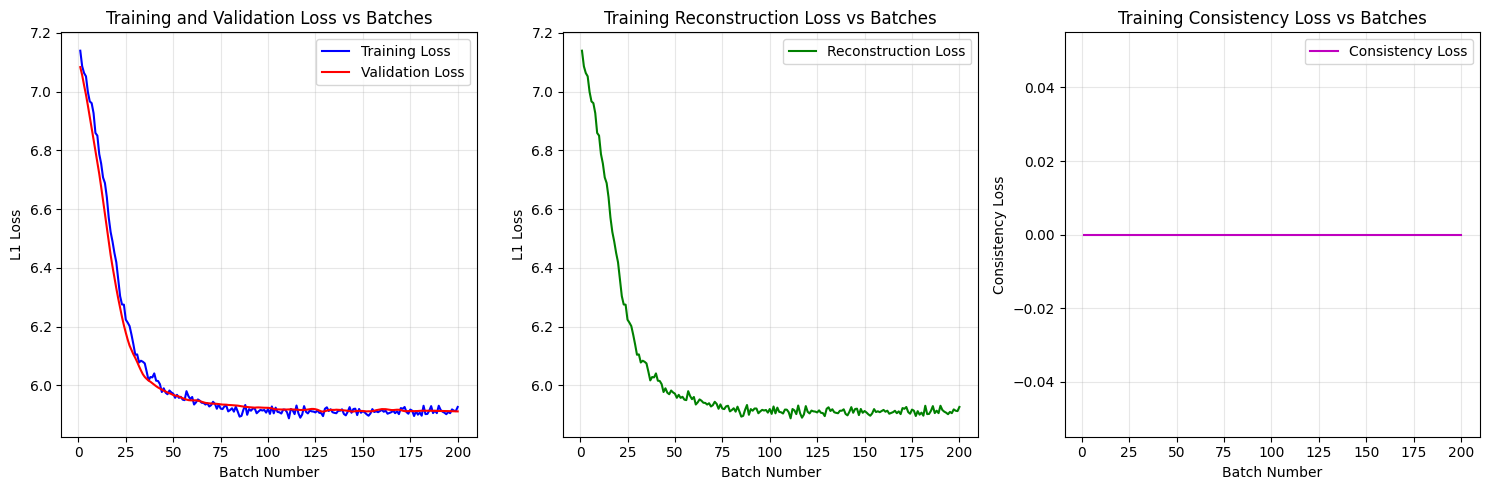

In [20]:
# Train the model using the fixed training function
print("\n" + "="*80)
print("Training attention model on transcriptomics...")
print("="*80 + "\n")

history_dynamics = train_attention_model(
    model=model_transcriptomics,
    train_dataset=train_dataset_transcriptomics,
    val_dataset=val_dataset_transcriptomics,
    config=CONFIG_TRANSCRIPTOMICS,
    device=device
)

# Plot training curves
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history_dynamics['batch_numbers'], history_dynamics['train_losses'], 'b-', label='Training Loss')
plt.plot(history_dynamics['batch_numbers'], history_dynamics['val_losses'], 'r-', label='Validation Loss')
plt.xlabel('Batch Number')
plt.ylabel('L1 Loss')
plt.title('Training and Validation Loss vs Batches')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(history_dynamics['batch_numbers'], history_dynamics['train_recon_losses'], 'g-', label='Reconstruction Loss')
plt.xlabel('Batch Number')
plt.ylabel('L1 Loss')
plt.title('Training Reconstruction Loss vs Batches')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(history_dynamics['batch_numbers'], history_dynamics['train_consistency_losses'], 'm-', label='Consistency Loss')
plt.xlabel('Batch Number')
plt.ylabel('Consistency Loss')
plt.title('Training Consistency Loss vs Batches')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Visualization of Learned Attention Matrices

Now we visualize the learned attention patterns. The attention weights represent our learned "connectome" - how much each neuron needs to attend to every other neuron for reconstruction. We'll focus on analyzing the structure and patterns in the learned attention matrix.


In [21]:
# Comprehensive Refactored Analysis Functions
def analyze_attention_matrix(model, dataset, neuron_labels, device, 
                                         use_attention_scores=False, sparsity_thresh=0.1,
                                         num_graph_targets=20, edge_thresh=0.25):
    """
    Extract and comprehensively analyze learned attention matrix.
    
    Args:
        model: trained SingleHeadSelfAttention model
        dataset: Dataset used for evaluation
        neuron_labels: list of neuron identifiers
        device: torch device
        use_attention_scores: whether to use scores or weights
        sparsity_thresh: threshold for sparsity calculation
        num_graph_targets: number of target neurons for graph visualization
        edge_thresh: threshold for edges in graph visualization
    
    Returns:
        dict with attention matrix and comprehensive analysis results
    """
    model.eval()
    
    # Collect attention matrices from all samples
    all_attn_weights = []
    all_attn_scores = []
    loader = DataLoader(dataset, batch_size=32, shuffle=False)
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            _, attn_weights, attn_scores = model(batch, mask_other=False)
            all_attn_weights.append(attn_weights.cpu().numpy())
            all_attn_scores.append(attn_scores.cpu().numpy())
    
    # Average across all samples
    all_attn_weights = np.concatenate(all_attn_weights, axis=0)
    all_attn_scores = np.concatenate(all_attn_scores, axis=0)
    
    attention_weights_matrix = all_attn_weights.mean(axis=0)  # (N, N)
    attention_scores_matrix = all_attn_scores.mean(axis=0)  # (N, N)
    
    # Choose which attention matrix to use
    if use_attention_scores:
        attention_matrix = attention_scores_matrix
        attention_type = "scores"
        attention_label = "Attention Score"
        cmap = 'coolwarm'
    else:
        attention_matrix = attention_weights_matrix
        attention_type = "weights"
        attention_label = "Attention Weight"
        cmap = 'plasma'
    
    # Calculate statistics
    attention_sparsity_val = (attention_weights_matrix < sparsity_thresh).sum() / attention_weights_matrix.size
    
    results = {
        'attention_matrix': attention_matrix,
        'attention_weights_matrix': attention_weights_matrix,
        'attention_scores_matrix': attention_scores_matrix,
        'neuron_labels': neuron_labels,
        'sparsity': attention_sparsity_val,
        'mean': attention_matrix.mean(),
        'std': attention_matrix.std(),
        'attention_type': attention_type,
        'attention_label': attention_label
    }
    
    # First figure: Attention matrix and graph view
    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # 1) Learned attention matrix with sparsified tick labels
    im1 = ax1.imshow(attention_matrix, cmap=cmap, aspect='auto')
    ax1.set_title(f'Learned Attention {attention_type.title()} (Batch Average)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Neuron')
    ax1.set_ylabel('Neuron')
    plt.colorbar(im1, ax=ax1, label=attention_label)
    
    # Label every k-th tick to reduce clutter
    k = max(1, len(neuron_labels) // 16)  # ~16 labels per axis
    xticks = np.arange(0, len(neuron_labels), k)
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([neuron_labels[i] for i in xticks], fontsize=6, rotation=90)
    ax1.set_yticks(xticks)
    ax1.set_yticklabels([neuron_labels[i] for i in xticks], fontsize=6)
    
    # 2) Graph plot for randomly selected target neurons
    targets = np.random.choice(len(neuron_labels), size=num_graph_targets, replace=False)
    G = nx.DiGraph()
    
    # Add nodes
    for idx in range(len(neuron_labels)):
        G.add_node(idx, label=neuron_labels[idx])
    
    # Add edges to selected targets above threshold (exclude self)
    for j in targets:  # j is target
        for i in range(len(neuron_labels)):  # i is source
            if i == j:
                continue
            w = attention_weights_matrix[j, i]  # [target, source] for incoming edges
            if w >= edge_thresh:
                G.add_edge(i, j, weight=w)  # Edge from source i to target j
    
    # Node positions (force-directed layout)
    if G.number_of_nodes() > 0:
        pos = nx.spring_layout(G, k=1, iterations=50)
        # Draw nodes (highlight selected targets)
        node_colors = ['orange' if n in targets else 'lightgray' for n in G.nodes()]
        nx.draw_networkx_nodes(G, pos, node_size=200, node_color=node_colors, ax=ax2)
        # Draw edges with widths ~ weight
        if G.number_of_edges() > 0:
            weights = np.array([d['weight'] for (_, _, d) in G.edges(data=True)])
            widths = 1.0 + 5.0 * (weights - weights.min()) / (np.ptp(weights) + 1e-8)
            nx.draw_networkx_edges(G, pos, width=widths, edge_color='steelblue', alpha=0.7, arrows=True, ax=ax2)
        # Draw labels for nodes
        labels = {n: neuron_labels[n] for n in G.nodes()}
        nx.draw_networkx_labels(G, pos, labels=labels, font_size=6, ax=ax2)
    
    ax2.set_title(f'Graph View: {num_graph_targets} Target Neurons (edge ≥ {edge_thresh})')
    ax2.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Second figure: Statistics plots
    fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
    
    # 1) Statistics text box
    ax1.axis('off')
    stats_text = f"""Attention {attention_type.title()} Statistics:
Shape: {attention_matrix.shape}
Mean: {attention_matrix.mean():.6f}
Std: {attention_matrix.std():.6f}
Max: {attention_matrix.max():.6f}
Min: {attention_matrix.min():.6f}
Diagonal Mean: {np.diag(attention_matrix).mean():.6f}
Sparsity (fraction < {sparsity_thresh}): {attention_sparsity_val:.3f}"""
    ax1.text(0.1, 0.5, stats_text, fontsize=12, verticalalignment='center',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))
    
    # 2) Value distributions
    ax2.hist(attention_matrix.flatten(), bins=50, alpha=0.7, color='blue', label='Attention')
    ax2.set_xlabel('Value')
    ax2.set_ylabel('Frequency')
    ax2.set_title(f'Attention {attention_type.title()} Distribution')
    ax2.set_yscale('log')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nSummary (Batch Average):")
    print(f"Using attention {attention_type}")
    print(f"Learned attention matrix shape: {attention_matrix.shape}")
    print(f"Attention matrix stats - mean: {attention_matrix.mean():.6f}, std: {attention_matrix.std():.6f}")
    print(f"Attention matrix range: [{attention_matrix.min():.6f}, {attention_matrix.max():.6f}]")
    print(f"Attention weights sparsity@{sparsity_thresh}: {attention_sparsity_val:.3f}")
    
    return results

print("Comprehensive refactored analysis functions defined")


Comprehensive refactored analysis functions defined


Analyzing learned attention matrix from transcriptomics phase...


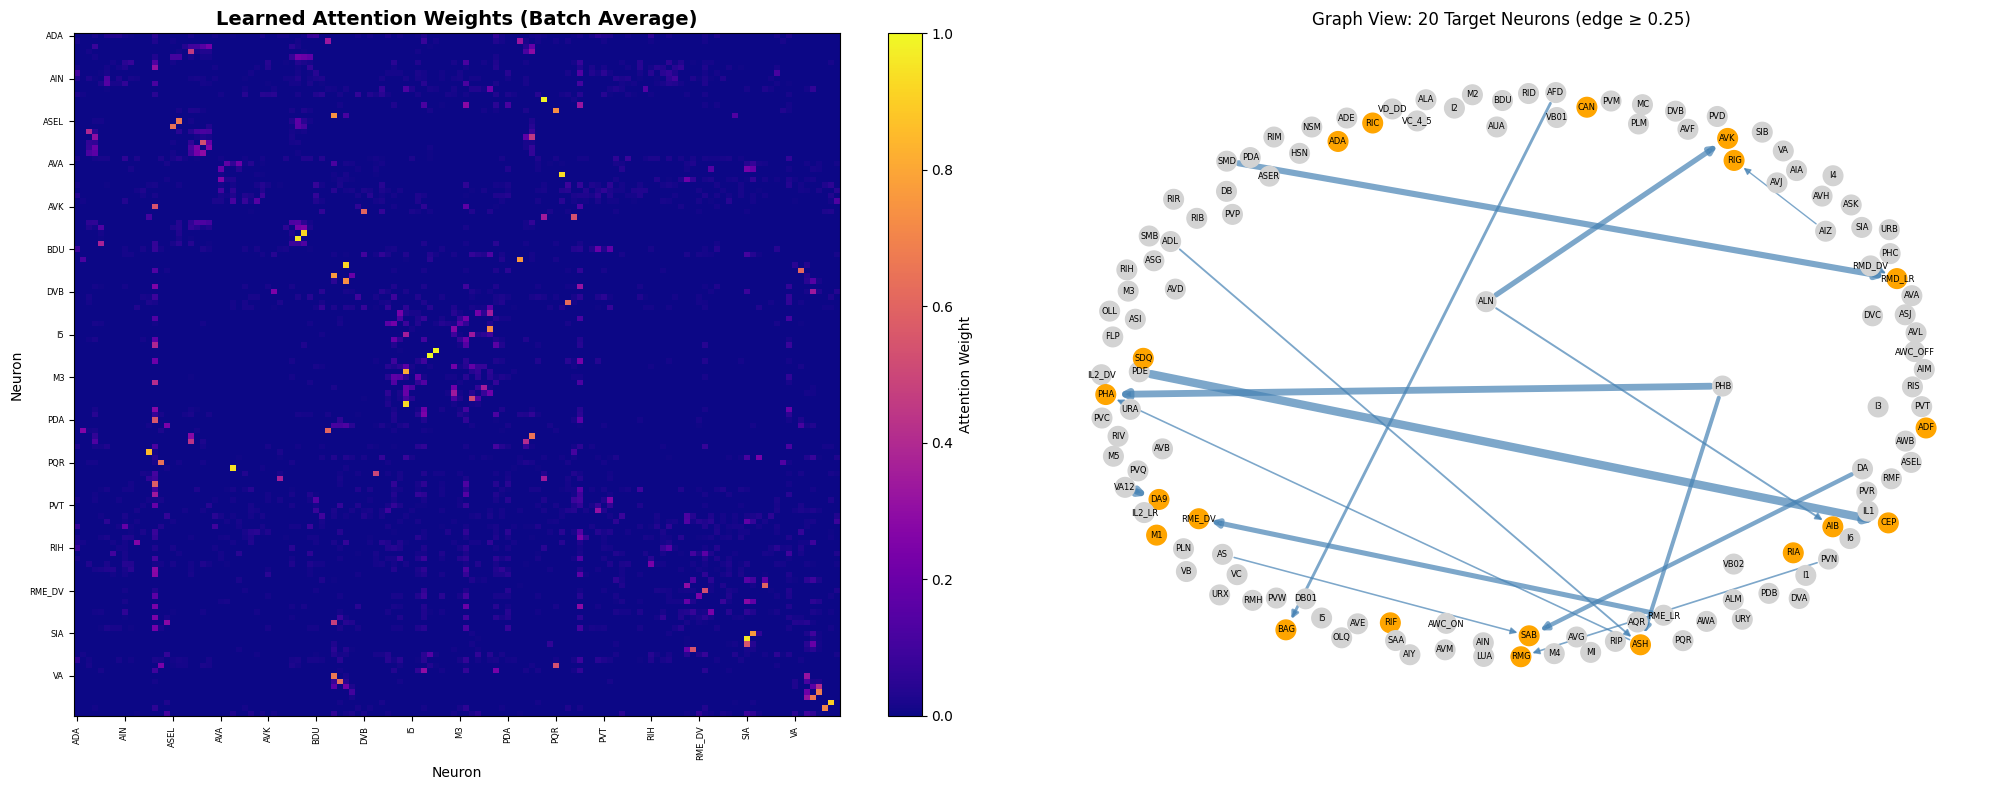

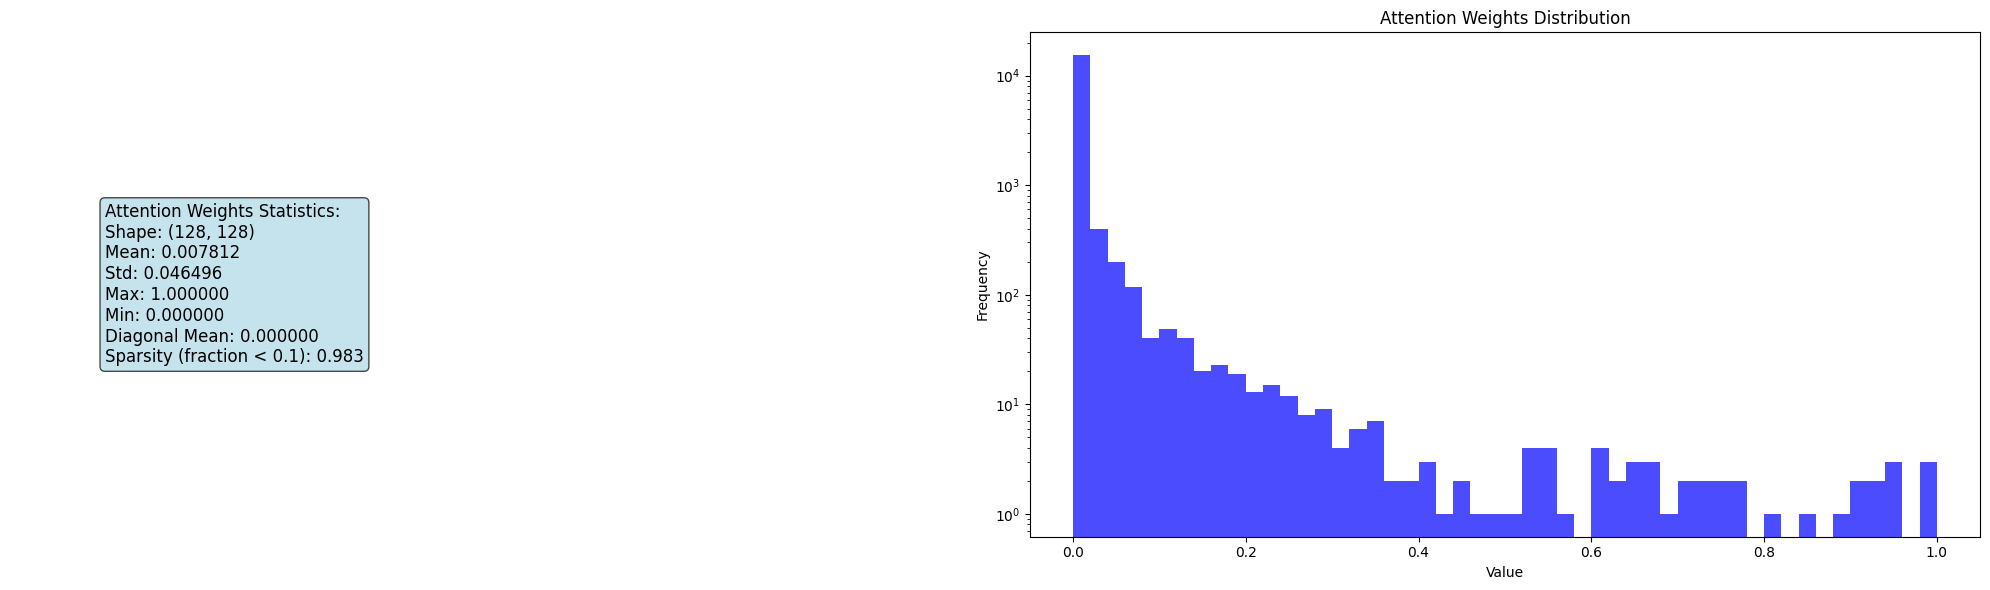


Summary (Batch Average):
Using attention weights
Learned attention matrix shape: (128, 128)
Attention matrix stats - mean: 0.007812, std: 0.046496
Attention matrix range: [0.000000, 1.000000]
Attention weights sparsity@0.1: 0.983


In [22]:
# Replace the transcriptomics visualization with modularized function
print("Analyzing learned attention matrix from transcriptomics phase...")

# Analyze using the comprehensive function
results_transcriptomics = analyze_attention_matrix(
    model=model_transcriptomics,
    dataset=val_dataset_transcriptomics,
    neuron_labels=neuron_classes,
    device=device,
    use_attention_scores=CONFIG_TRANSCRIPTOMICS['use_attention_scores'],
    sparsity_thresh=0.1,
    num_graph_targets=20,
    edge_thresh=0.25
)

# Store results for later comparison
attention_matrix_transcriptomics = results_transcriptomics['attention_matrix']

### **Idea**: Does the learned attention matrix better embed neurons? 

If we interpret the attention matrix as a similarity matrix, does it induce a semantically meaningful clustering of neurons, such as by cell-type or neurotransmitters?

We can load additional neuron metadata from `data/neuron_master_sheet.csv` to use as unsupervised labels.

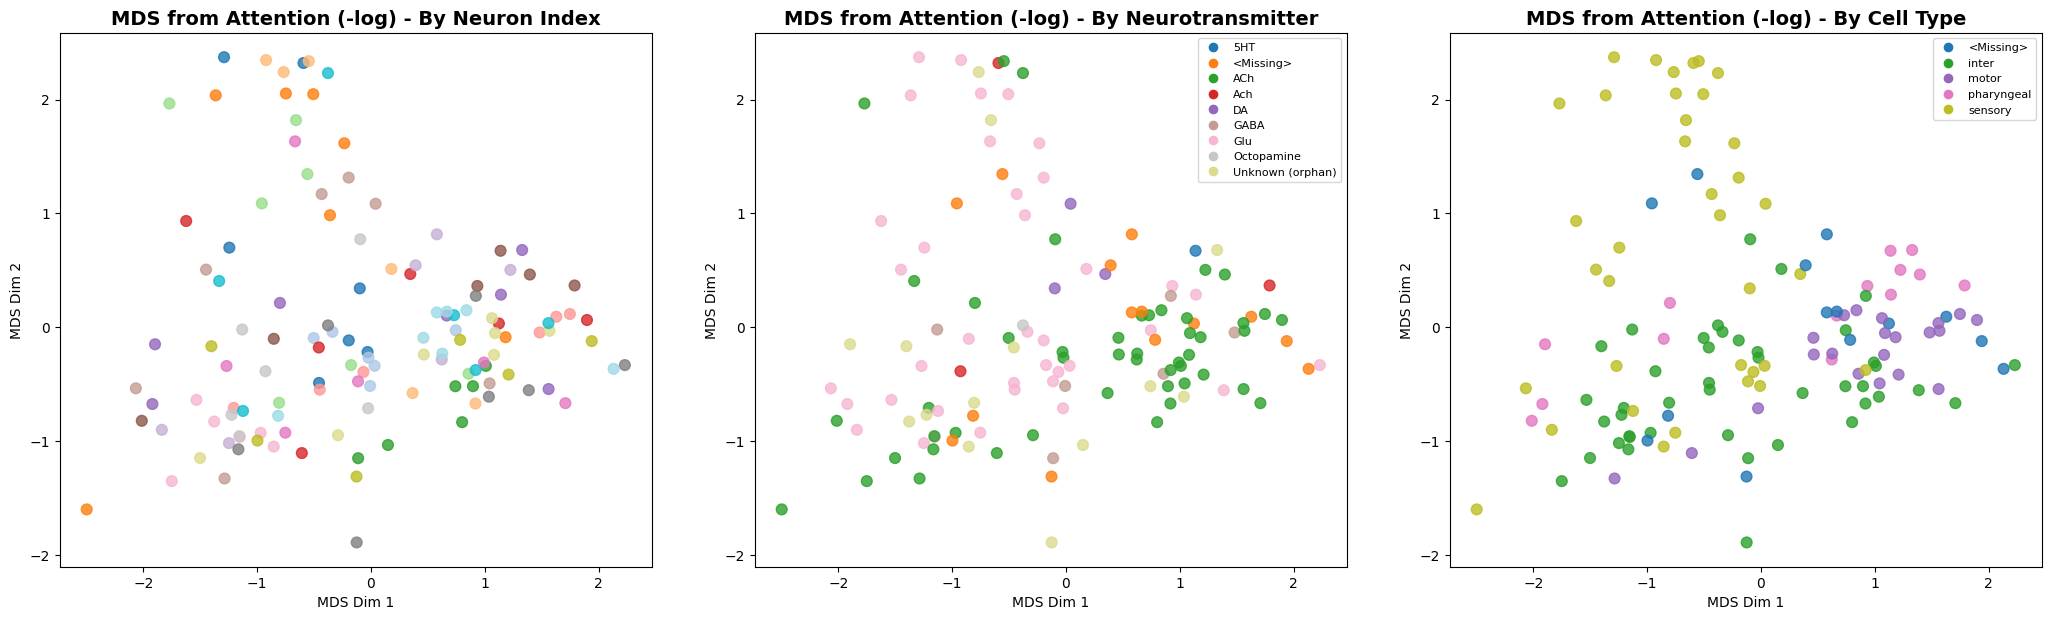

In [23]:
# Similarity → Information Distance → Classical MDS
# - Use the learned attention matrix A (rows softmaxed)
# - Symmetrize to get similarity S in [0,1]
# - Convert S to a steeper "information" distance with -log
# - Classical MDS from distances

# ----- Use the learned attention matrix -----
A = attention_matrix_transcriptomics

# Symmetrize to get a similarity matrix S \in [0,1]
# S = 0.5 * (A + A.T)

# If the learnt attention matrix is already approximately symmetric
S = A 
n = S.shape[0]
J = np.eye(n) - np.ones((n, n)) / n

# ----- Similarity -> Distance (steeper than sqrt(1-S)) -----
# Information distance: D_ij = sqrt(max(0, -log(S_ij + eps)))
eps = 1e-9
D = np.sqrt(np.maximum(0.0, -np.log(S + eps)))

# ----- Classical MDS from pairwise distances -----
# Double-centering turns squared distances into a centered Gram matrix
B = -0.5 * J @ (D ** 2) @ J

# Eigendecomposition of Gram matrix; take top 2 components
eigvals, eigvecs = np.linalg.eigh(B)
idx = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]

# Keep top 2 nonnegative components (guard against tiny negatives)
k = min(2, int((eigvals > 1e-12).sum()))
coords_mds = eigvecs[:, :k] * np.sqrt(np.maximum(eigvals[:k], 0.0))

# ----- Plot: 3-panel visualization with metadata coloring -----
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Prepare colormaps - use actual colors instead of indices
cmap = plt.cm.tab20
nt_color_values = [cmap(nt_to_color[nt] / len(unique_nt)) for nt in neuron_neurotransmitters]
type_color_values = [cmap(type_to_color[t] / len(unique_types)) for t in neuron_types]

# Plot 1: By neuron index
ax = axes[0]
scatter = ax.scatter(coords_mds[:, 0], coords_mds[:, 1],
                    c=range(len(neuron_classes)), cmap='tab20', s=60, alpha=0.8)
ax.set_title('MDS from Attention (-log) - By Neuron Index', fontsize=14, fontweight='bold')
ax.set_xlabel('MDS Dim 1')
ax.set_ylabel('MDS Dim 2')
ax.set_aspect('equal')

# Plot 2: By neurotransmitter
ax = axes[1]
scatter = ax.scatter(coords_mds[:, 0], coords_mds[:, 1],
                    c=nt_color_values, s=60, alpha=0.8)  # Use actual colors, not cmap
ax.set_title('MDS from Attention (-log) - By Neurotransmitter', fontsize=14, fontweight='bold')
ax.set_xlabel('MDS Dim 1')
ax.set_ylabel('MDS Dim 2')
ax.set_aspect('equal')

# Add legend for neurotransmitters
handles = [plt.Line2D([0], [0], marker='o', color='w', 
                     markerfacecolor=cmap(nt_to_color[nt]/len(unique_nt)), 
                     markersize=8, label=nt) for nt in unique_nt]
ax.legend(handles=handles, loc='best', fontsize=8)

# Plot 3: By cell type
ax = axes[2]
scatter = ax.scatter(coords_mds[:, 0], coords_mds[:, 1],
                    c=type_color_values, s=60, alpha=0.8)  # Use actual colors, not cmap
ax.set_title('MDS from Attention (-log) - By Cell Type', fontsize=14, fontweight='bold')
ax.set_xlabel('MDS Dim 1')
ax.set_ylabel('MDS Dim 2')
ax.set_aspect('equal')

# Add legend for types
handles = [plt.Line2D([0], [0], marker='o', color='w', 
                     markerfacecolor=cmap(type_to_color[t]/len(unique_types)), 
                     markersize=8, label=t) for t in unique_types]
ax.legend(handles=handles, loc='best', fontsize=8)

plt.tight_layout()
plt.show()

## 8. Ground-Truth Connectome Data Loading and Analysis

Now we'll load and analyze ground-truth connectome data to compare with our learned attention matrix. We have access to:

1. **Witvliet 2020 data** (`witvliet_2020_7.csv`, `witvliet_2020_8.csv`): From "Connectomes across development reveal principles of brain maturation" (Nature 596, 257–261, 2021)
2. **Randi 2023 data** (`CElegansFunctionalConnectivity.xlsx`): From "Neural signal propagation atlas of Caenorhabditis elegans" (Nature 623, 406–414, 2023)

These provide both structural (wired) and functional connectivity data that we can compare against our learned attention patterns.


In [24]:
# Convert ground-truth connectome data to combined adjacency matrix
print("Creating combined Witvliet 2020 connectome (averaged and symmetrized)...")

def create_adjacency_matrix(df, neuron_list, weight_col='synapses', synapse_type='chemical'):
    """Create adjacency matrix from connectome dataframe, filtering by synapse type."""
    n_neurons = len(neuron_list)
    adj_matrix = np.zeros((n_neurons, n_neurons))
    
    # Create mapping from neuron names to indices
    neuron_to_idx = {neuron: i for i, neuron in enumerate(neuron_list)}
    
    # Filter for only the specified synapse type
    df_filtered = df[df['type'] == synapse_type]
    print(f"  Using {synapse_type} synapses: {len(df_filtered)} connections")
    
    for _, row in df_filtered.iterrows():
        pre_neuron = row['pre']
        post_neuron = row['post']
        weight = row[weight_col]
        
        if pre_neuron in neuron_to_idx and post_neuron in neuron_to_idx:
            pre_idx = neuron_to_idx[pre_neuron]
            post_idx = neuron_to_idx[post_neuron]
            adj_matrix[pre_idx, post_idx] += weight  # Sum if multiple connections
    
    return adj_matrix
    

Creating combined Witvliet 2020 connectome (averaged and symmetrized)...


In [25]:
# Load and analyze Witvliet 2020 connectome data
print("Loading Witvliet 2020 connectome data...")

# Load both datasets (they are tab-separated)
witvliet_7 = pd.read_csv('data/connectomics/witvliet_2020_7.csv', sep='\t')
witvliet_8 = pd.read_csv('data/connectomics/witvliet_2020_8.csv', sep='\t')

print(f"Witvliet 2020-7 shape: {witvliet_7.shape}")
print(f"Witvliet 2020-8 shape: {witvliet_8.shape}")
print(f"\nWitvliet 2020-7 columns: {witvliet_7.columns.tolist()}")
print(f"Witvliet 2020-8 columns: {witvliet_8.columns.tolist()}")

# Display sample data
print(f"\nWitvliet 2020-7 sample:")
print(witvliet_7.head())
print(f"\nWitvliet 2020-8 sample:")
print(witvliet_8.head())

# Analyze unique neurons in each dataset, filtering out BWM (body-wall muscle) neurons
neurons_7_pre = {n for n in witvliet_7['pre'].unique() if not n.startswith('BWM-')}
neurons_7_post = {n for n in witvliet_7['post'].unique() if not n.startswith('BWM-')}
neurons_7_all = neurons_7_pre.union(neurons_7_post)

neurons_8_pre = {n for n in witvliet_8['pre'].unique() if not n.startswith('BWM-')}
neurons_8_post = {n for n in witvliet_8['post'].unique() if not n.startswith('BWM-')}
neurons_8_all = neurons_8_pre.union(neurons_8_post)

# Union of all neurons across both datasets
neurons_7_8_all = neurons_7_all.union(neurons_8_all)

# Intersection of neurons across both datasets
neurons_7_8_overlap = neurons_7_all.intersection(neurons_8_all)

print(f"\nNeuron analysis:")
print(f"Witvliet 2020-7: {len(neurons_7_all)} unique neurons")
print(f"Witvliet 2020-8: {len(neurons_8_all)} unique neurons")
print(f"Union: {len(neurons_7_8_all)} neurons")
print(f"Overlap between 7 and 8: {len(neurons_7_8_overlap)} neurons")

# Check overlap with our transcriptome neuron classes
transcriptome_neurons = {n for n in neuron_classes if not n.startswith('BWM-')}
overlap_with_transcriptome = transcriptome_neurons.intersection(neurons_7_8_all)

print(f"\nOverlap with transcriptome data:")
print(f"Combined Witvliet overlap: {len(overlap_with_transcriptome)}/{len(transcriptome_neurons)} ({len(overlap_with_transcriptome)/len(transcriptome_neurons)*100:.1f}%)")
print(f"Sample overlapping neurons: {list(overlap_with_transcriptome)[:10]}")

# Analyze connection types
print(f"\nConnection type analysis:")
print(f"Witvliet 2020-7 types: {witvliet_7['type'].value_counts().to_dict()}")
print(f"Witvliet 2020-8 types: {witvliet_8['type'].value_counts().to_dict()}")

Loading Witvliet 2020 connectome data...
Witvliet 2020-7 shape: (2493, 4)
Witvliet 2020-8 shape: (2496, 4)

Witvliet 2020-7 columns: ['pre', 'post', 'type', 'synapses']
Witvliet 2020-8 columns: ['pre', 'post', 'type', 'synapses']

Witvliet 2020-7 sample:
    pre  post      type  synapses
0  ADAL  AIAL  chemical         2
1  ADAL  AIBL  chemical         2
2  ADAL  AIBR  chemical         1
3  ADAL  AVAL  chemical         1
4  ADAL  AVBL  chemical         7

Witvliet 2020-8 sample:
    pre  post        type  synapses
0  ADAL  ADAR  electrical         1
1  ADAL  ASHL  electrical         1
2  ADAL  AVAL    chemical         2
3  ADAL  AVAR    chemical         1
4  ADAL  AVBL    chemical        16

Neuron analysis:
Witvliet 2020-7: 190 unique neurons
Witvliet 2020-8: 187 unique neurons
Union: 191 neurons
Overlap between 7 and 8: 186 neurons

Overlap with transcriptome data:
Combined Witvliet overlap: 14/128 (10.9%)
Sample overlapping neurons: ['PVR', 'RID', 'AQR', 'AVM', 'DVA', 'ASEL', 'ASER'

In [26]:
# Create full adjacency matrices for all neurons in union (chemical synapses only)
all_neurons = sorted(list(neurons_7_8_all))  # Sort for consistent ordering
print(f"\nCreating adjacency matrices for {len(all_neurons)} neurons...")

print("Witvliet 2020-7:")
gt_adj_7_full = create_adjacency_matrix(witvliet_7, all_neurons, synapse_type='chemical')

print("Witvliet 2020-8:")
gt_adj_8_full = create_adjacency_matrix(witvliet_8, all_neurons, synapse_type='chemical')

# Average element-wise (treating missing connections as 0)
gt_adj_combined = (gt_adj_7_full + gt_adj_8_full) / 2
print(f"\nCombined adjacency matrix shape: {gt_adj_combined.shape}")
print(f"Combined matrix stats - mean: {gt_adj_combined.mean():.6f}, std: {gt_adj_combined.std():.6f}, max: {gt_adj_combined.max():.1f}")

# Extract submatrix for overlapping neurons with transcriptome
overlap_neurons = sorted(list(overlap_with_transcriptome))  # Sort for consistent ordering
print(f"\nUsing {len(overlap_neurons)} overlapping neurons for comparison")

overlap_indices_gt = [all_neurons.index(n) for n in overlap_neurons]
overlap_indices_attn = [neuron_classes.index(n) for n in overlap_neurons]

gt_adj_final = gt_adj_combined[np.ix_(overlap_indices_gt, overlap_indices_gt)]
attention_submatrix = attention_matrix_transcriptomics[np.ix_(overlap_indices_attn, overlap_indices_attn)]

print(f"Ground-truth adjacency matrix (final) shape: {gt_adj_final.shape}")
print(f"Attention submatrix shape: {attention_submatrix.shape}")

print(f"\nFinal matrix statistics:")
print(f"GT Combined (Chemical): mean={gt_adj_final.mean():.6f}, std={gt_adj_final.std():.6f}, max={gt_adj_final.max():.1f}")
print(f"Attention: mean={attention_submatrix.mean():.6f}, std={attention_submatrix.std():.6f}, max={attention_submatrix.max():.6f}")

# Define attention type and label for consistency with visualization code
if CONFIG_TRANSCRIPTOMICS['use_attention_scores']:
    attention_type = "scores"
    attention_label = "Attention Score"
else:
    attention_type = "weights"
    attention_label = "Attention Weight"



Creating adjacency matrices for 191 neurons...
Witvliet 2020-7:
  Using chemical synapses: 2202 connections
Witvliet 2020-8:
  Using chemical synapses: 2186 connections

Combined adjacency matrix shape: (191, 191)
Combined matrix stats - mean: 0.189181, std: 1.224797, max: 36.5

Using 14 overlapping neurons for comparison
Ground-truth adjacency matrix (final) shape: (14, 14)
Attention submatrix shape: (14, 14)

Final matrix statistics:
GT Combined (Chemical): mean=0.221939, std=0.961227, max=7.5
Attention: mean=0.013014, std=0.069496, max=0.667852



COMPREHENSIVE MATRIX VISUALIZATION: Full vs Submatrices



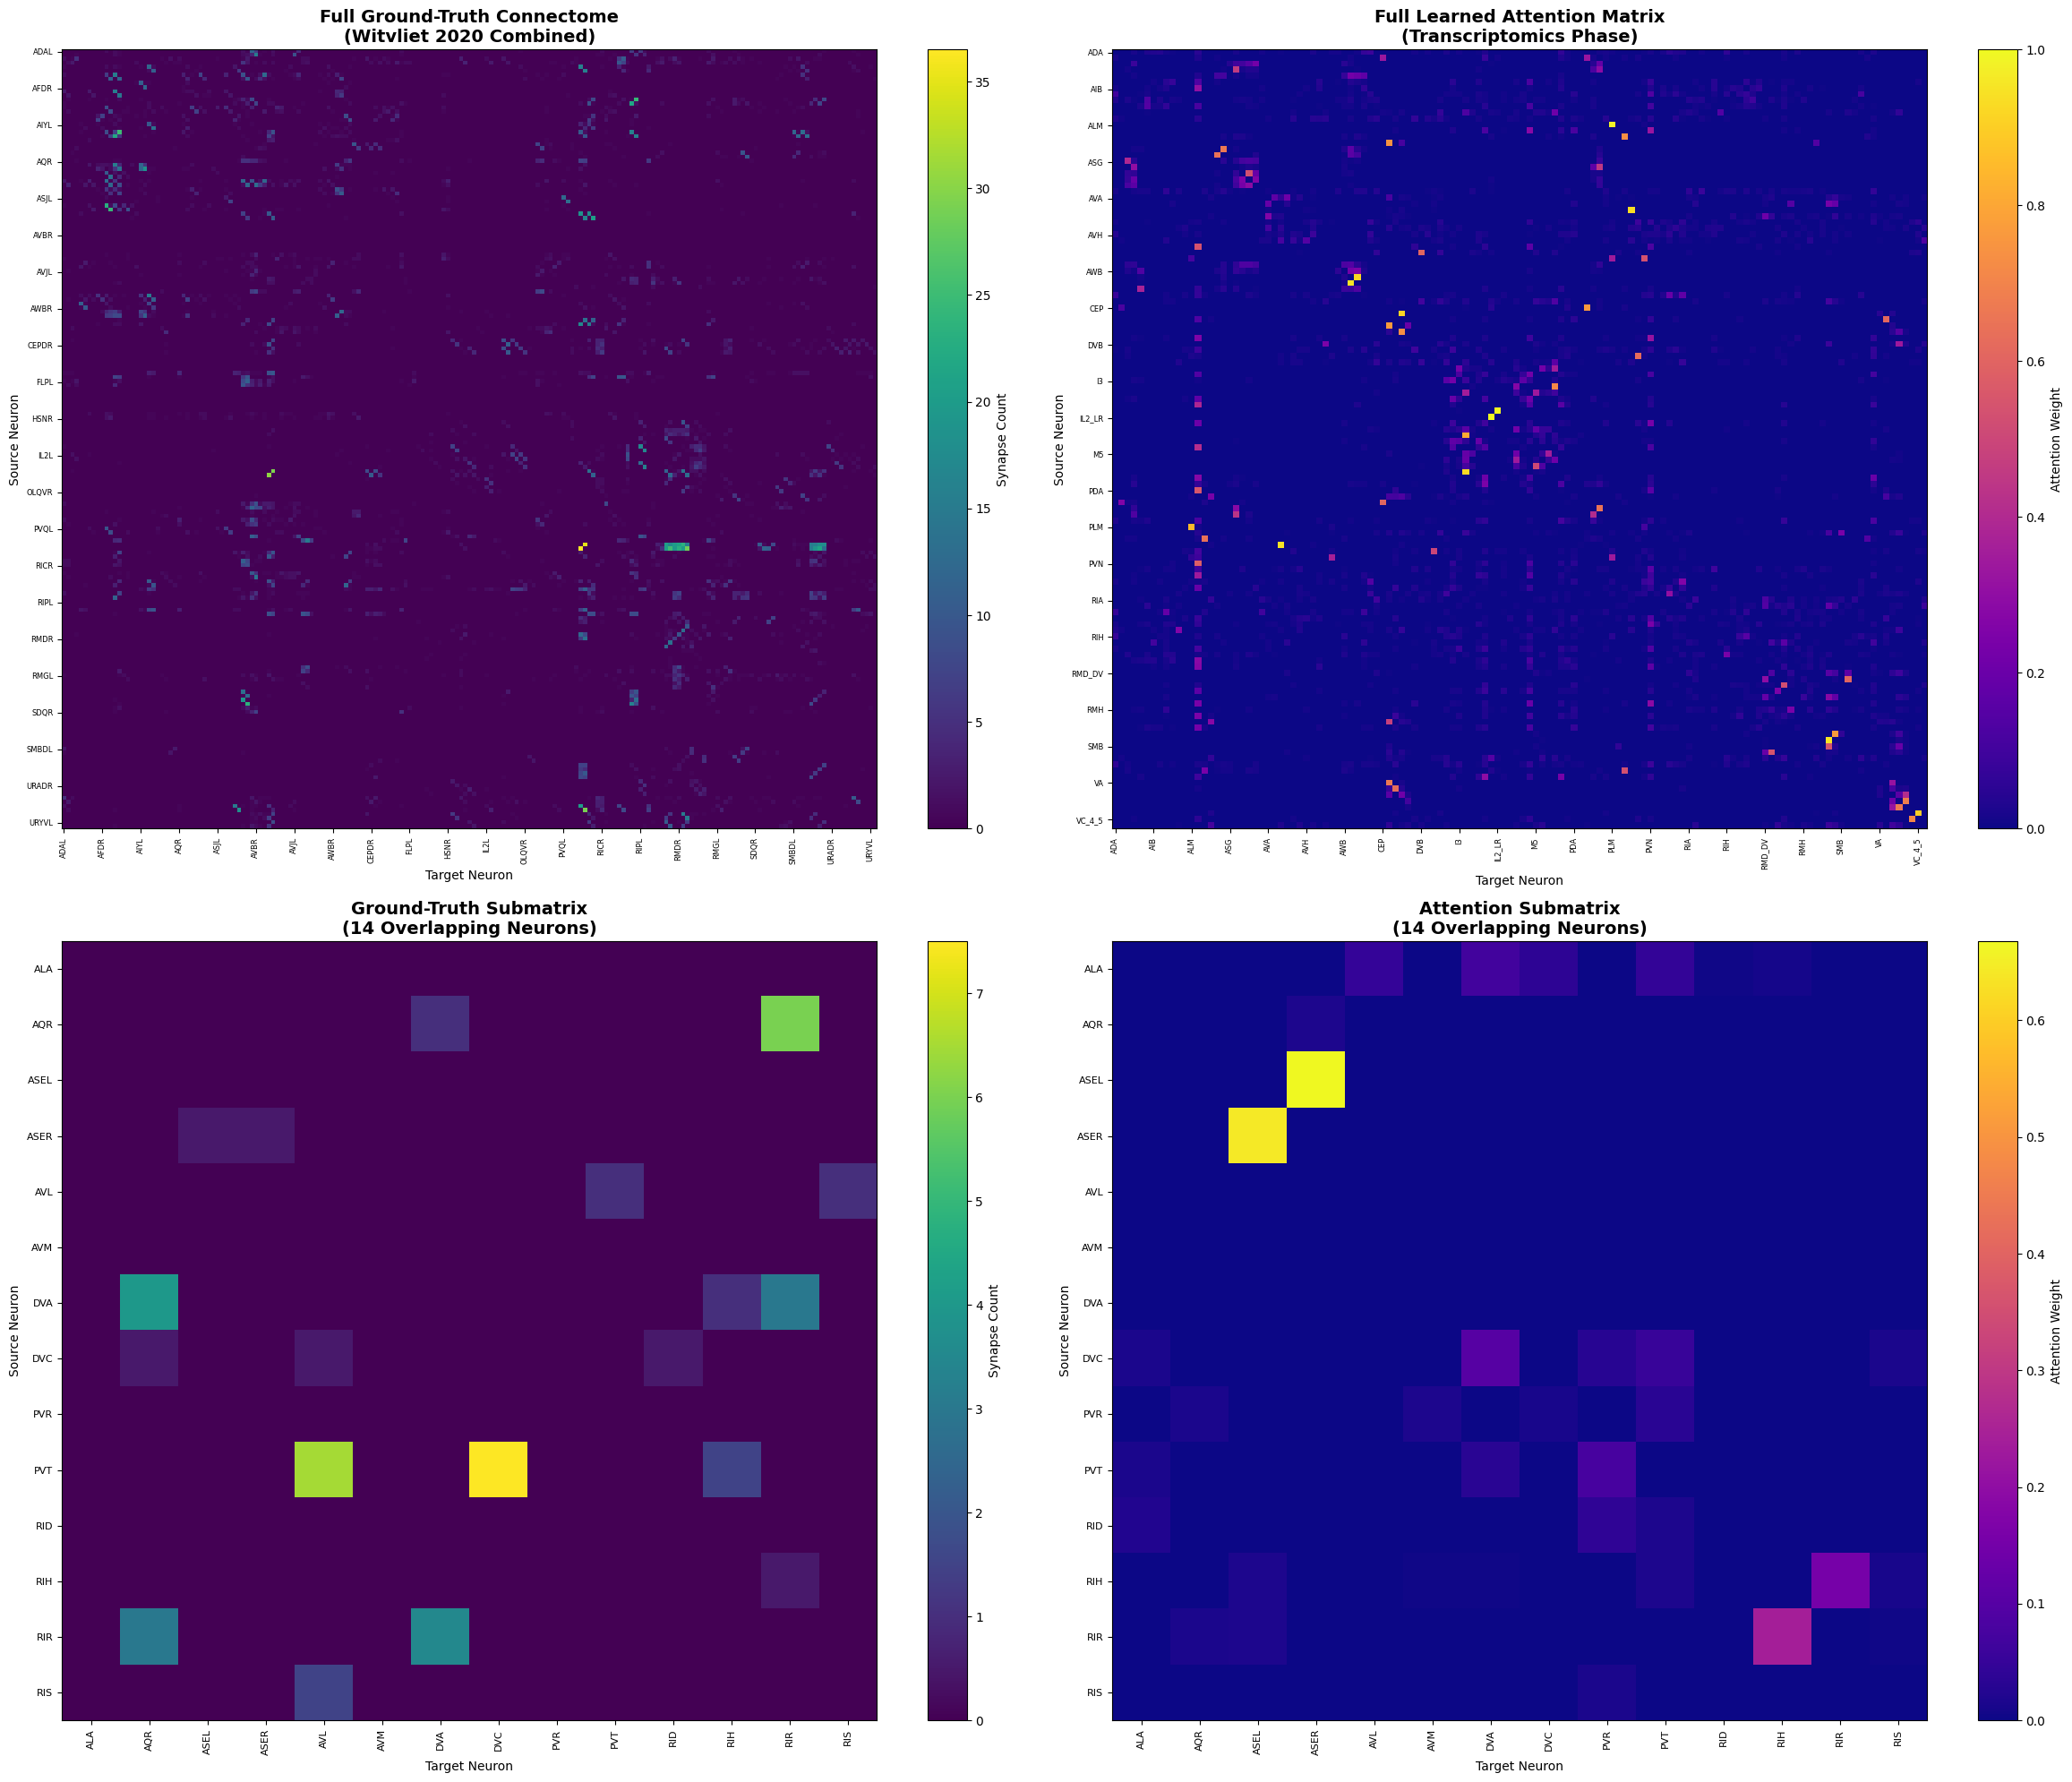


MATRIX STATISTICS COMPARISON

FULL MATRICES:
Ground-Truth Connectome:
  Shape: (191, 191)
  Mean: 0.189181
  Std: 1.224797
  Max: 36.5
  Sparsity: 0.927

Learned Attention Matrix:
  Shape: (128, 128)
  Mean: 0.007812
  Std: 0.046496
  Max: 1.000000
  Sparsity: 0.876

SUBMATRICES (Overlapping Neurons):
Ground-Truth Submatrix:
  Shape: (14, 14)
  Mean: 0.221939
  Std: 0.961227
  Max: 7.5
  Sparsity: 0.903

Attention Submatrix:
  Shape: (14, 14)
  Mean: 0.013014
  Std: 0.069496
  Max: 0.667852
  Sparsity: 0.847

OVERLAP INFORMATION:
Total neurons in ground-truth: 191
Total neurons in transcriptomics: 128
Overlapping neurons: 14
Overlap percentage: 7.3%


In [27]:
# Comprehensive Matrix Visualization: Full vs Submatrices
print("\n" + "="*80)
print("COMPREHENSIVE MATRIX VISUALIZATION: Full vs Submatrices")
print("="*80 + "\n")

# Create 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(24, 20))

# Top row: Full matrices
# 1) Full ground-truth connectome
im1 = axes[0, 0].imshow(gt_adj_combined, cmap='viridis', aspect='auto')
axes[0, 0].set_title('Full Ground-Truth Connectome\n(Witvliet 2020 Combined)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Target Neuron')
axes[0, 0].set_ylabel('Source Neuron')
plt.colorbar(im1, ax=axes[0, 0], label='Synapse Count')

# Label every k-th tick to reduce clutter for full matrix
k_full = max(1, len(all_neurons) // 20)  # ~20 labels per axis
xticks_full = np.arange(0, len(all_neurons), k_full)
axes[0, 0].set_xticks(xticks_full)
axes[0, 0].set_xticklabels([all_neurons[i] for i in xticks_full], fontsize=6, rotation=90)
axes[0, 0].set_yticks(xticks_full)
axes[0, 0].set_yticklabels([all_neurons[i] for i in xticks_full], fontsize=6)

# 2) Full learned attention matrix
im2 = axes[0, 1].imshow(attention_matrix_transcriptomics, cmap='plasma', aspect='auto')
axes[0, 1].set_title('Full Learned Attention Matrix\n(Transcriptomics Phase)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Target Neuron')
axes[0, 1].set_ylabel('Source Neuron')
plt.colorbar(im2, ax=axes[0, 1], label='Attention Weight')

# Label every k-th tick to reduce clutter for full matrix
k_attn = max(1, len(neuron_classes) // 20)  # ~20 labels per axis
xticks_attn = np.arange(0, len(neuron_classes), k_attn)
axes[0, 1].set_xticks(xticks_attn)
axes[0, 1].set_xticklabels([neuron_classes[i] for i in xticks_attn], fontsize=6, rotation=90)
axes[0, 1].set_yticks(xticks_attn)
axes[0, 1].set_yticklabels([neuron_classes[i] for i in xticks_attn], fontsize=6)

# Bottom row: Submatrices (overlapping neurons)
# 3) Ground-truth submatrix
im3 = axes[1, 0].imshow(gt_adj_final, cmap='viridis', aspect='auto')
axes[1, 0].set_title(f'Ground-Truth Submatrix\n({len(overlap_neurons)} Overlapping Neurons)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Target Neuron')
axes[1, 0].set_ylabel('Source Neuron')
plt.colorbar(im3, ax=axes[1, 0], label='Synapse Count')

# Label all neurons in submatrix (should be manageable)
axes[1, 0].set_xticks(range(len(overlap_neurons)))
axes[1, 0].set_xticklabels(overlap_neurons, fontsize=8, rotation=90)
axes[1, 0].set_yticks(range(len(overlap_neurons)))
axes[1, 0].set_yticklabels(overlap_neurons, fontsize=8)

# 4) Attention submatrix
im4 = axes[1, 1].imshow(attention_submatrix, cmap='plasma', aspect='auto')
axes[1, 1].set_title(f'Attention Submatrix\n({len(overlap_neurons)} Overlapping Neurons)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Target Neuron')
axes[1, 1].set_ylabel('Source Neuron')
plt.colorbar(im4, ax=axes[1, 1], label='Attention Weight')

# Label all neurons in submatrix
axes[1, 1].set_xticks(range(len(overlap_neurons)))
axes[1, 1].set_xticklabels(overlap_neurons, fontsize=8, rotation=90)
axes[1, 1].set_yticks(range(len(overlap_neurons)))
axes[1, 1].set_yticklabels(overlap_neurons, fontsize=8)

plt.tight_layout()
plt.show()

# Print comprehensive statistics
print("\n" + "="*60)
print("MATRIX STATISTICS COMPARISON")
print("="*60)

print(f"\nFULL MATRICES:")
print(f"Ground-Truth Connectome:")
print(f"  Shape: {gt_adj_combined.shape}")
print(f"  Mean: {gt_adj_combined.mean():.6f}")
print(f"  Std: {gt_adj_combined.std():.6f}")
print(f"  Max: {gt_adj_combined.max():.1f}")
print(f"  Sparsity: {(gt_adj_combined == 0).sum() / gt_adj_combined.size:.3f}")

print(f"\nLearned Attention Matrix:")
print(f"  Shape: {attention_matrix_transcriptomics.shape}")
print(f"  Mean: {attention_matrix_transcriptomics.mean():.6f}")
print(f"  Std: {attention_matrix_transcriptomics.std():.6f}")
print(f"  Max: {attention_matrix_transcriptomics.max():.6f}")
print(f"  Sparsity: {(attention_matrix_transcriptomics < 0.01).sum() / attention_matrix_transcriptomics.size:.3f}")

print(f"\nSUBMATRICES (Overlapping Neurons):")
print(f"Ground-Truth Submatrix:")
print(f"  Shape: {gt_adj_final.shape}")
print(f"  Mean: {gt_adj_final.mean():.6f}")
print(f"  Std: {gt_adj_final.std():.6f}")
print(f"  Max: {gt_adj_final.max():.1f}")
print(f"  Sparsity: {(gt_adj_final == 0).sum() / gt_adj_final.size:.3f}")

print(f"\nAttention Submatrix:")
print(f"  Shape: {attention_submatrix.shape}")
print(f"  Mean: {attention_submatrix.mean():.6f}")
print(f"  Std: {attention_submatrix.std():.6f}")
print(f"  Max: {attention_submatrix.max():.6f}")
print(f"  Sparsity: {(attention_submatrix < 0.01).sum() / attention_submatrix.size:.3f}")

print(f"\nOVERLAP INFORMATION:")
print(f"Total neurons in ground-truth: {len(all_neurons)}")
print(f"Total neurons in transcriptomics: {len(neuron_classes)}")
print(f"Overlapping neurons: {len(overlap_neurons)}")
print(f"Overlap percentage: {len(overlap_neurons) / max(len(all_neurons), len(neuron_classes)) * 100:.1f}%")

# ============================================================================
# PHASE 2: NEURAL DYNAMICS
# ============================================================================

## Overview
Replace transcriptomic embeddings with neural dynamics time series as the representation to reconstruct. Train the same `SingleHeadSelfAttention` model to learn how neurons attend to each other's temporal activity patterns. Compare results with Phase 1 (transcriptomics).


In [28]:
# Configuration for neural dynamics phase
CONFIG_DYNAMICS = {
    'seq_len': 512,           # Temporal window length (embedding dimension)
    'stride': 1,               # Sliding window stride
    'hidden_dim': 1024,         # Hidden dimension for Q/K/V
    'batch_size': 8,          # Batch size
    'learning_rate': 1e-3,     # Learning rate
    'use_attention_scores': False, # Use attention scores instead of weights
    'consistency_weight': 0.0, # Batch consistency regularization
    'consistency_type': 'variance',  # 'variance' or 'frobenius'
    'train_val_split': 0.5,    # Train/validation split
}

print("Phase 2 Configuration (Neural Dynamics):")
for key, value in CONFIG_DYNAMICS.items():
    print(f"  {key}: {value}")


Phase 2 Configuration (Neural Dynamics):
  seq_len: 512
  stride: 1
  hidden_dim: 1024
  batch_size: 8
  learning_rate: 0.001
  use_attention_scores: False
  consistency_weight: 0.0
  consistency_type: variance
  train_val_split: 0.5


In [29]:
# Initialize model for dynamics phase
# d_model = seq_len (temporal window is the "embedding")
model_dynamics = SingleHeadSelfAttention(
    d_model=CONFIG_DYNAMICS['seq_len'],
    n_hidden=CONFIG_DYNAMICS['hidden_dim'],
    use_attention_scores=False
).to(device)

print(f"\nModel architecture:")
print(f"  d_model (seq_len): {CONFIG_DYNAMICS['seq_len']}")
print(f"  n_hidden: {CONFIG_DYNAMICS['hidden_dim']}")
print(f"  Total parameters: {sum(p.numel() for p in model_dynamics.parameters()):,}")



Model architecture:
  d_model (seq_len): 512
  n_hidden: 1024
  Total parameters: 1,048,576


In [30]:
# Load processed neural dynamics data
# NOTE: First run notebooks/load_neural_dynamics.ipynb to process the JSON files
dynamics_file = Path('data/dynamics/wormwideweb/processed/atanas_kim_2023-2022-06-14-01_processed.npz')
# Fix: Update data loading for new structure
print("Updating data loading for new structure...")

# Reload with correct structure
with np.load(dynamics_file, allow_pickle=True) as data:
    trace_array = data['trace_array']      # (N_neurons, T) - already filtered to labeled neurons
    neuron_labels = data['neuron_labels'].tolist()  # List of neuron labels
    neuron_classes = data['neuron_classes'].tolist()  # List of neuron classes
    labeled_indices = data['labeled_indices'].tolist()  # Original indices in full array
    metadata = data['metadata'].item()

print(f"Updated neural dynamics data:")
print(f"  Source: {metadata['source']}")
print(f"  N_neurons (labeled): {metadata['n_neurons']}")
print(f"  N_timepoints: {metadata['n_timepoints']}")
print(f"  N_total_neurons: {metadata['n_total_neurons']}")
print(f"  Shape: {trace_array.shape}")
print(f"  Neuron labels: {len(neuron_labels)}")
print(f"  Neuron classes: {len(neuron_classes)}")

# Store neuron count
N_neurons_dynamics = trace_array.shape[0]


Updating data loading for new structure...
Updated neural dynamics data:
  Source: atanas_kim_2023-2022-06-14-01.json
  N_neurons (labeled): 79
  N_timepoints: 1600
  N_total_neurons: 109
  Shape: (79, 1600)
  Neuron labels: 79
  Neuron classes: 79


In [31]:
# NeuralDynamicsDataset for Phase 2
class NeuralDynamicsDataset(Dataset):
    """
    Dataset that creates overlapping temporal windows from neural activity time series.
    Each sample is a (N_neurons, seq_len) tensor representing a temporal chunk.
    """
    
    def __init__(self, trace_array, seq_len, stride=1, device='cpu'):
        """
        Args:
            trace_array: (N_neurons, T) numpy array of neural activity
            seq_len: length of each temporal window
            stride: stride for sliding window (default=1 for maximum overlap)
            device: torch device to move data to
        """
        self.trace_array = trace_array  # (N_neurons, T)
        self.seq_len = seq_len
        self.stride = stride
        self.device = device
        
        self.N_neurons, self.T = trace_array.shape
        
        # Calculate number of possible windows
        self.n_windows = (self.T - seq_len) // stride + 1
        
        print(f"\nNeuralDynamicsDataset:")
        print(f"  N_neurons: {self.N_neurons}")
        print(f"  Total timepoints: {self.T}")
        print(f"  seq_len: {seq_len}")
        print(f"  stride: {stride}")
        print(f"  n_windows: {self.n_windows}")
    
    def __len__(self):
        return self.n_windows
    
    def __getitem__(self, idx):
        """
        Returns:
            tensor of shape (N_neurons, seq_len)
        """
        start_idx = idx * self.stride
        end_idx = start_idx + self.seq_len
        
        # Extract window
        window = self.trace_array[:, start_idx:end_idx]  # (N_neurons, seq_len)
        
        # Convert to tensor and move to device
        window_tensor = torch.tensor(window, dtype=torch.float32, device=self.device)
        
        return window_tensor


In [32]:
# Calculate train/val split
T_total = trace_array.shape[1]
train_end_time = int(T_total * CONFIG_DYNAMICS['train_val_split'])

# Split time series temporally
train_trace = trace_array[:, train_end_time:] 
val_trace = trace_array[:, :train_end_time] # Make validation set the first part

print(f"Data split:")
print(f"  Train: {train_trace.shape}")
print(f"  Val: {val_trace.shape}")

# Create datasets
train_dataset_dynamics = NeuralDynamicsDataset(
    trace_array=train_trace,
    seq_len=CONFIG_DYNAMICS['seq_len'],
    stride=CONFIG_DYNAMICS['stride'],
    device=device
)

val_dataset_dynamics = NeuralDynamicsDataset(
    trace_array=val_trace,
    seq_len=CONFIG_DYNAMICS['seq_len'],
    stride=CONFIG_DYNAMICS['stride'],
    device=device
)

Data split:
  Train: (79, 800)
  Val: (79, 800)

NeuralDynamicsDataset:
  N_neurons: 79
  Total timepoints: 800
  seq_len: 512
  stride: 1
  n_windows: 289

NeuralDynamicsDataset:
  N_neurons: 79
  Total timepoints: 800
  seq_len: 512
  stride: 1
  n_windows: 289



Training attention model on neural dynamics...

	Batch 10 - Recon: 0.509605, Consistency: 0.000000, Total: 0.509605, Val: 0.585661, LR: 0.001000
	Batch 20 - Recon: 0.493817, Consistency: 0.000000, Total: 0.493817, Val: 0.565766, LR: 0.001000
	Batch 30 - Recon: 0.480063, Consistency: 0.000000, Total: 0.480063, Val: 0.542766, LR: 0.001000


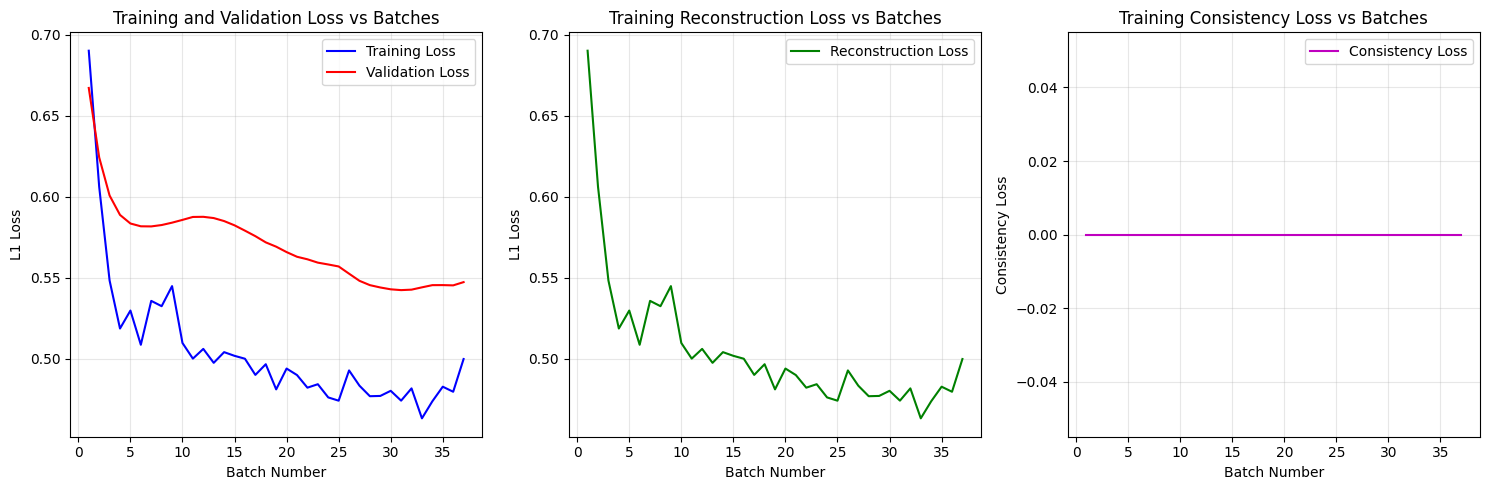

In [33]:
# Train the model using the fixed training function
print("\n" + "="*80)
print("Training attention model on neural dynamics...")
print("="*80 + "\n")

history_dynamics = train_attention_model(
    model=model_dynamics,
    train_dataset=train_dataset_dynamics,
    val_dataset=val_dataset_dynamics,
    config=CONFIG_DYNAMICS,
    device=device
)

# Plot training curves
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history_dynamics['batch_numbers'], history_dynamics['train_losses'], 'b-', label='Training Loss')
plt.plot(history_dynamics['batch_numbers'], history_dynamics['val_losses'], 'r-', label='Validation Loss')
plt.xlabel('Batch Number')
plt.ylabel('L1 Loss')
plt.title('Training and Validation Loss vs Batches')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(history_dynamics['batch_numbers'], history_dynamics['train_recon_losses'], 'g-', label='Reconstruction Loss')
plt.xlabel('Batch Number')
plt.ylabel('L1 Loss')
plt.title('Training Reconstruction Loss vs Batches')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(history_dynamics['batch_numbers'], history_dynamics['train_consistency_losses'], 'm-', label='Consistency Loss')
plt.xlabel('Batch Number')
plt.ylabel('Consistency Loss')
plt.title('Training Consistency Loss vs Batches')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


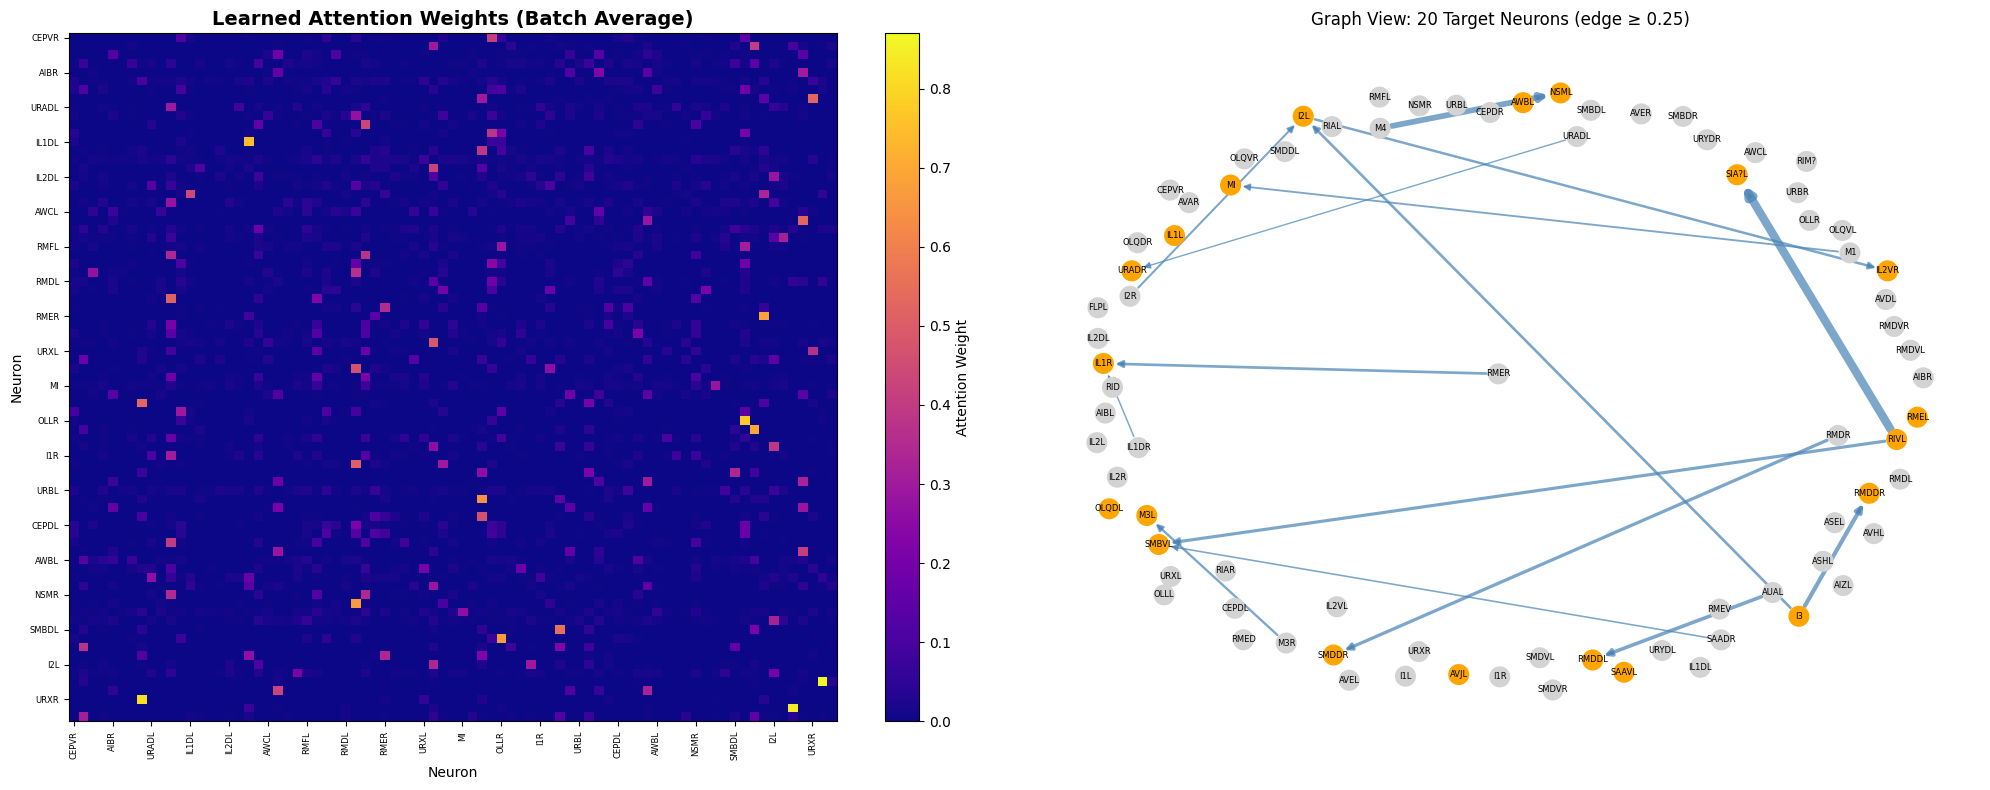

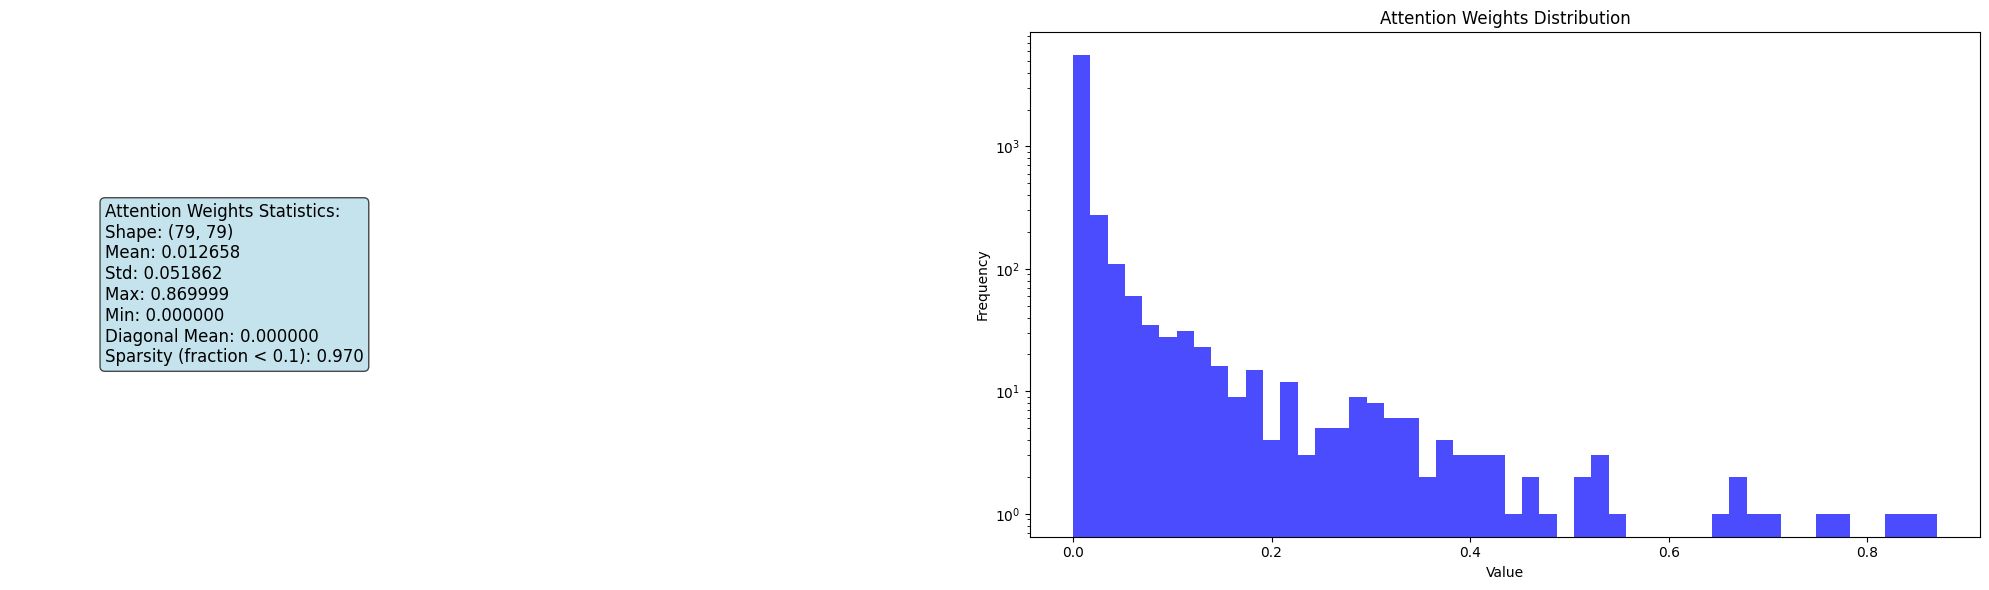


Summary (Batch Average):
Using attention weights
Learned attention matrix shape: (79, 79)
Attention matrix stats - mean: 0.012658, std: 0.051862
Attention matrix range: [0.000000, 0.869999]
Attention weights sparsity@0.1: 0.970

Dynamics Phase Results:
  Attention matrix shape: (79, 79)
  Sparsity: 0.970
  Mean attention weight: 0.012658
  Std attention weight: 0.051862
Analyzing learned attention matrix from neural dynamics phase...


In [37]:
# Analyze learned attention matrix from neural dynamics phase
results_dynamics = analyze_attention_matrix(
    model=model_dynamics,
    dataset=val_dataset_dynamics,
    neuron_labels=neuron_labels,
    device=device,
    use_attention_scores=CONFIG_DYNAMICS['use_attention_scores'],
    sparsity_thresh=0.1,
    num_graph_targets=20,
    edge_thresh=0.25
)

# Store results for later comparison
attention_matrix_dynamics = results_dynamics['attention_matrix']

print(f"\nDynamics Phase Results:")
print(f"  Attention matrix shape: {results_dynamics['attention_matrix'].shape}")
print(f"  Sparsity: {results_dynamics['sparsity']:.3f}")
print(f"  Mean attention weight: {results_dynamics['mean']:.6f}")
print(f"  Std attention weight: {results_dynamics['std']:.6f}")

# Analyze learned attention matrix from neural dynamics phase
print("Analyzing learned attention matrix from neural dynamics phase...")



COMPARISON: Phase 1 (Transcriptomics) vs Phase 2 (Neural Dynamics)



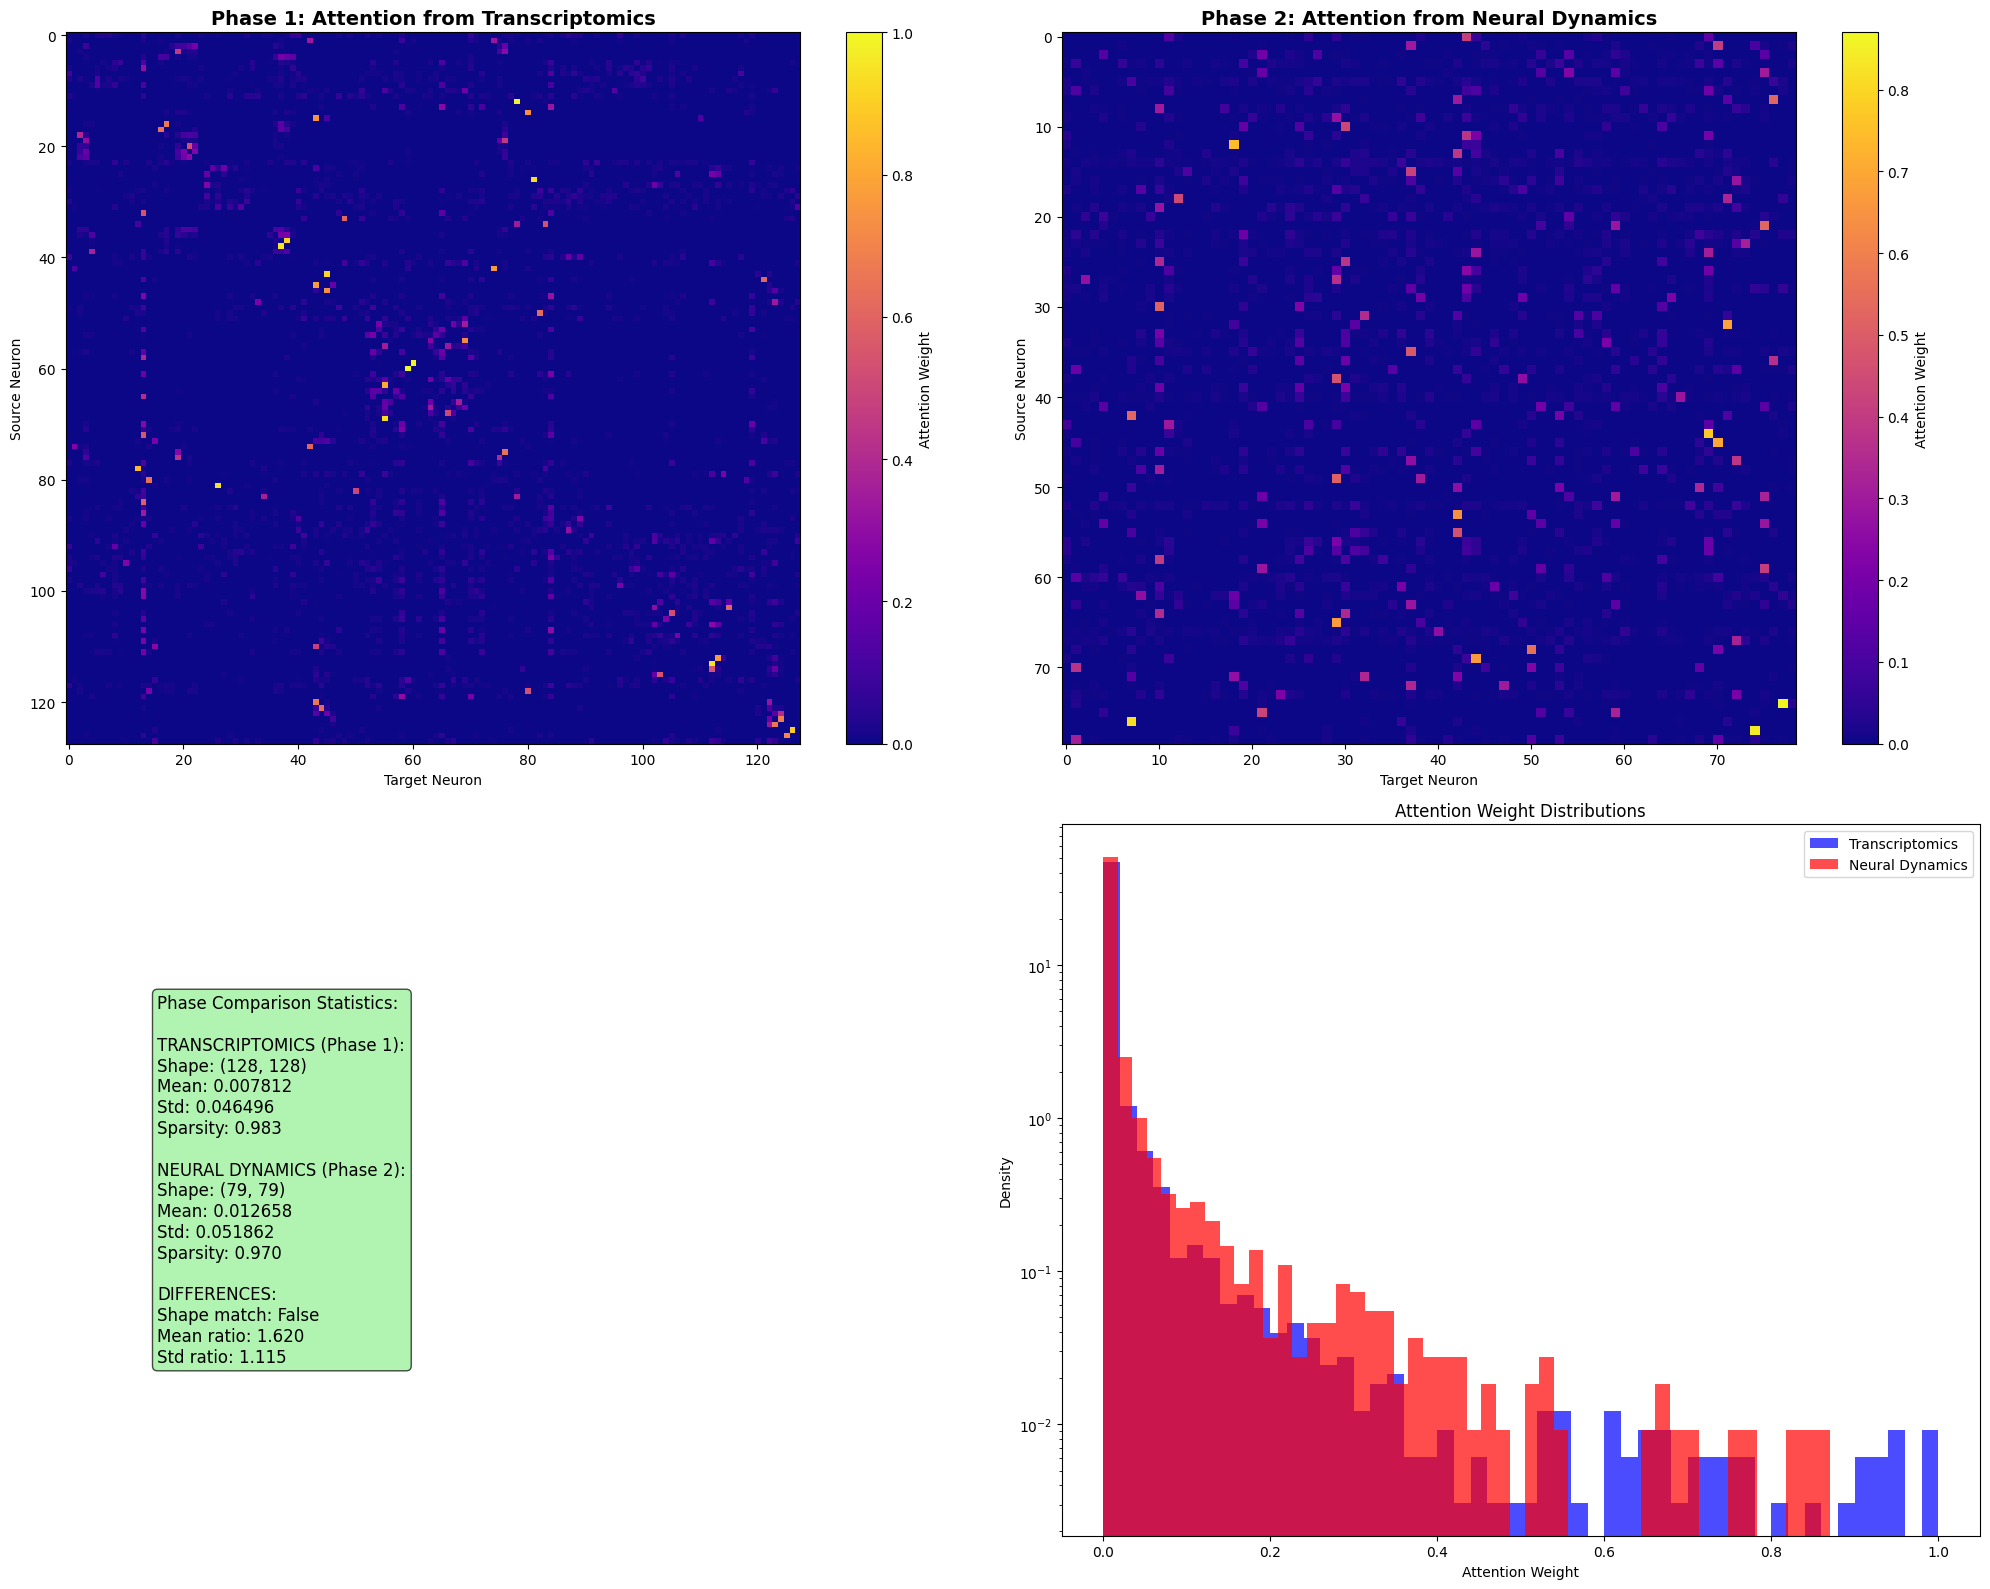

Comparison completed!


In [38]:
# Compare Phase 1 (Transcriptomics) vs Phase 2 (Dynamics)
print("\n" + "="*80)
print("COMPARISON: Phase 1 (Transcriptomics) vs Phase 2 (Neural Dynamics)")
print("="*80 + "\n")

fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# Phase 1: Transcriptomics
im1 = axes[0, 0].imshow(attention_matrix_transcriptomics, cmap='plasma', aspect='auto')
axes[0, 0].set_title('Phase 1: Attention from Transcriptomics', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Target Neuron')
axes[0, 0].set_ylabel('Source Neuron')
plt.colorbar(im1, ax=axes[0, 0], label='Attention Weight')

# Phase 2: Dynamics
im2 = axes[0, 1].imshow(attention_matrix_dynamics, cmap='plasma', aspect='auto')
axes[0, 1].set_title('Phase 2: Attention from Neural Dynamics', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Target Neuron')
axes[0, 1].set_ylabel('Source Neuron')
plt.colorbar(im2, ax=axes[0, 1], label='Attention Weight')

# Statistics comparison
axes[1, 0].axis('off')
comparison_text = f"""Phase Comparison Statistics:

TRANSCRIPTOMICS (Phase 1):
Shape: {attention_matrix_transcriptomics.shape}
Mean: {attention_matrix_transcriptomics.mean():.6f}
Std: {attention_matrix_transcriptomics.std():.6f}
Sparsity: {results_transcriptomics['sparsity']:.3f}

NEURAL DYNAMICS (Phase 2):
Shape: {attention_matrix_dynamics.shape}
Mean: {attention_matrix_dynamics.mean():.6f}
Std: {attention_matrix_dynamics.std():.6f}
Sparsity: {results_dynamics['sparsity']:.3f}

DIFFERENCES:
Shape match: {attention_matrix_transcriptomics.shape == attention_matrix_dynamics.shape}
Mean ratio: {attention_matrix_dynamics.mean() / attention_matrix_transcriptomics.mean():.3f}
Std ratio: {attention_matrix_dynamics.std() / attention_matrix_transcriptomics.std():.3f}"""
axes[1, 0].text(0.1, 0.5, comparison_text, fontsize=12, verticalalignment='center',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7))

# Distribution comparison
axes[1, 1].hist(attention_matrix_transcriptomics.flatten(), bins=50, alpha=0.7, 
                color='blue', label='Transcriptomics', density=True)
axes[1, 1].hist(attention_matrix_dynamics.flatten(), bins=50, alpha=0.7, 
                color='red', label='Neural Dynamics', density=True)
axes[1, 1].set_xlabel('Attention Weight')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Attention Weight Distributions')
axes[1, 1].legend()
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.show()

print("Comparison completed!")


In [39]:
# Find overlap between neural dynamics neurons and ground truth connectome
print("\n" + "="*80)
print("NEURAL DYNAMICS vs GROUND TRUTH OVERLAP ANALYSIS")
print("="*80 + "\n")

# Get neural dynamics neuron labels (these are the actual neuron names from the JSON)
dynamics_neurons = set(neuron_labels)
print(f"Neural dynamics neurons: {len(dynamics_neurons)}")
print(f"Sample dynamics neurons: {list(dynamics_neurons)[:10]}")

# Find overlap with ground truth connectome
overlap_dynamics_gt = dynamics_neurons.intersection(neurons_7_8_all)
print(f"\nOverlap with ground truth connectome:")
print(f"  Dynamics neurons: {len(dynamics_neurons)}")
print(f"  Ground truth neurons: {len(neurons_7_8_all)}")
print(f"  Overlapping neurons: {len(overlap_dynamics_gt)}")
print(f"  Overlap percentage: {len(overlap_dynamics_gt) / len(dynamics_neurons) * 100:.1f}%")
print(f"  Sample overlapping neurons: {list(overlap_dynamics_gt)[:10]}")

# Create submatrices for overlapping neurons
if len(overlap_dynamics_gt) > 0:
    overlap_neurons_dynamics = sorted(list(overlap_dynamics_gt))
    
    # Get indices for ground truth matrix
    overlap_indices_gt_dynamics = [all_neurons.index(n) for n in overlap_neurons_dynamics]
    
    # Get indices for dynamics attention matrix
    overlap_indices_dynamics = [neuron_labels.index(n) for n in overlap_neurons_dynamics]
    
    # Extract submatrices
    gt_adj_dynamics = gt_adj_combined[np.ix_(overlap_indices_gt_dynamics, overlap_indices_gt_dynamics)]
    attention_submatrix_dynamics = attention_matrix_dynamics[np.ix_(overlap_indices_dynamics, overlap_indices_dynamics)]
    
    print(f"\nSubmatrix shapes:")
    print(f"  Ground truth submatrix: {gt_adj_dynamics.shape}")
    print(f"  Dynamics attention submatrix: {attention_submatrix_dynamics.shape}")
    
    print(f"\nSubmatrix statistics:")
    print(f"  GT submatrix - mean: {gt_adj_dynamics.mean():.6f}, std: {gt_adj_dynamics.std():.6f}, max: {gt_adj_dynamics.max():.1f}")
    print(f"  Dynamics attention - mean: {attention_submatrix_dynamics.mean():.6f}, std: {attention_submatrix_dynamics.std():.6f}, max: {attention_submatrix_dynamics.max():.6f}")
    
else:
    print("No overlapping neurons found between dynamics and ground truth!")
    overlap_neurons_dynamics = []
    gt_adj_dynamics = np.array([])
    attention_submatrix_dynamics = np.array([])


NEURAL DYNAMICS vs GROUND TRUTH OVERLAP ANALYSIS

Neural dynamics neurons: 79
Sample dynamics neurons: ['AIBL', 'RIAL', 'NSMR', 'SIA?L', 'URYDR', 'AWBL', 'URBR', 'RMDDR', 'RMDR', 'RID']

Overlap with ground truth connectome:
  Dynamics neurons: 79
  Ground truth neurons: 191
  Overlapping neurons: 65
  Overlap percentage: 82.3%
  Sample overlapping neurons: ['AIBL', 'RIAL', 'RMEV', 'RIAR', 'URXR', 'URYDR', 'AVDL', 'SMBVL', 'AWBL', 'SMDVL']

Submatrix shapes:
  Ground truth submatrix: (65, 65)
  Dynamics attention submatrix: (65, 65)

Submatrix statistics:
  GT submatrix - mean: 0.432544, std: 2.257677, max: 36.5
  Dynamics attention - mean: 0.012791, std: 0.054220, max: 0.869999



COMPREHENSIVE MATRIX VISUALIZATION: Dynamics vs Ground Truth



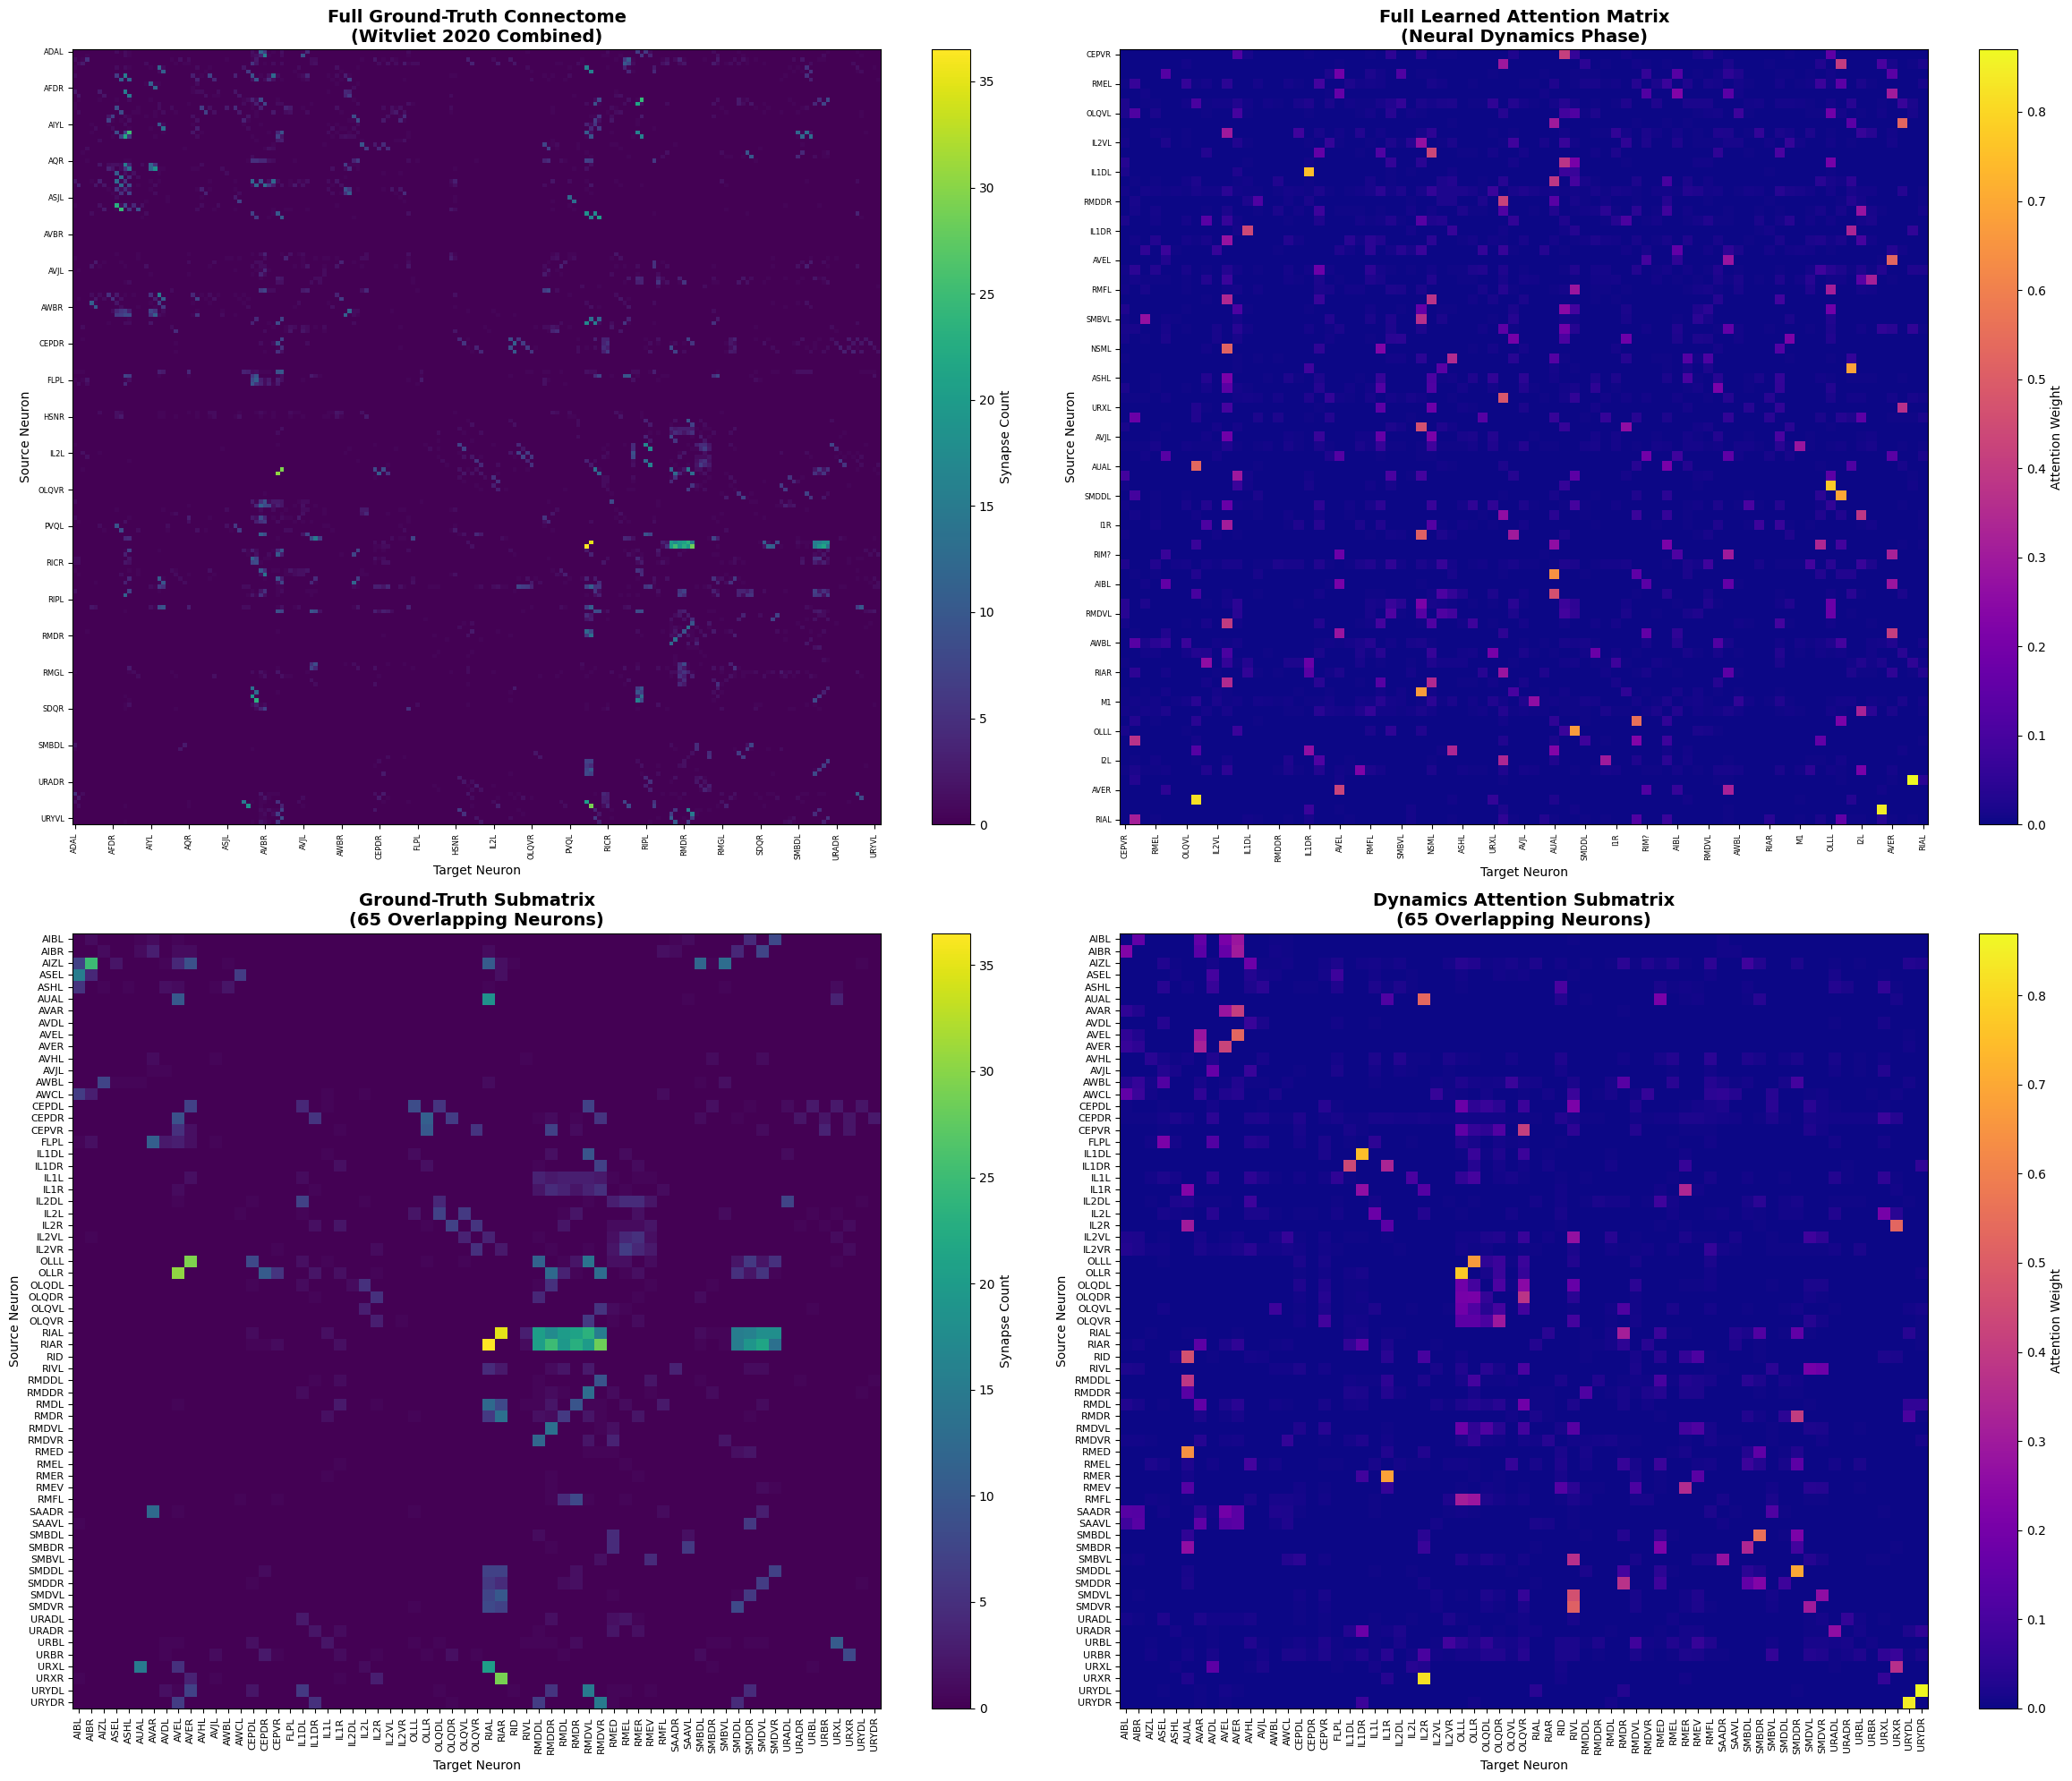


DYNAMICS MATRIX STATISTICS COMPARISON

FULL MATRICES:
Ground-Truth Connectome:
  Shape: (191, 191)
  Mean: 0.189181
  Std: 1.224797
  Max: 36.5
  Sparsity: 0.927

Learned Attention Matrix (Dynamics):
  Shape: (79, 79)
  Mean: 0.012658
  Std: 0.051862
  Max: 0.869999
  Sparsity: 0.839

SUBMATRICES (Overlapping Neurons):
Ground-Truth Submatrix:
  Shape: (65, 65)
  Mean: 0.432544
  Std: 2.257677
  Max: 36.5
  Sparsity: 0.888

Dynamics Attention Submatrix:
  Shape: (65, 65)
  Mean: 0.012791
  Std: 0.054220
  Max: 0.869999
  Sparsity: 0.837

OVERLAP INFORMATION:
Total neurons in ground-truth: 191
Total neurons in dynamics: 79
Overlapping neurons: 65
Overlap percentage: 34.0%


In [40]:
# Comprehensive Matrix Visualization: Dynamics vs Ground Truth
print("\n" + "="*80)
print("COMPREHENSIVE MATRIX VISUALIZATION: Dynamics vs Ground Truth")
print("="*80 + "\n")

if len(overlap_dynamics_gt) > 0:
    # Create 2x2 subplot layout
    fig, axes = plt.subplots(2, 2, figsize=(24, 20))
    
    # Top row: Full matrices
    # 1) Full ground-truth connectome
    im1 = axes[0, 0].imshow(gt_adj_combined, cmap='viridis', aspect='auto')
    axes[0, 0].set_title('Full Ground-Truth Connectome\n(Witvliet 2020 Combined)', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Target Neuron')
    axes[0, 0].set_ylabel('Source Neuron')
    plt.colorbar(im1, ax=axes[0, 0], label='Synapse Count')
    
    # Label every k-th tick to reduce clutter for full matrix
    k_full = max(1, len(all_neurons) // 20)  # ~20 labels per axis
    xticks_full = np.arange(0, len(all_neurons), k_full)
    axes[0, 0].set_xticks(xticks_full)
    axes[0, 0].set_xticklabels([all_neurons[i] for i in xticks_full], fontsize=6, rotation=90)
    axes[0, 0].set_yticks(xticks_full)
    axes[0, 0].set_yticklabels([all_neurons[i] for i in xticks_full], fontsize=6)
    
    # 2) Full learned attention matrix (dynamics)
    im2 = axes[0, 1].imshow(attention_matrix_dynamics, cmap='plasma', aspect='auto')
    axes[0, 1].set_title('Full Learned Attention Matrix\n(Neural Dynamics Phase)', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Target Neuron')
    axes[0, 1].set_ylabel('Source Neuron')
    plt.colorbar(im2, ax=axes[0, 1], label='Attention Weight')
    
    # Label every k-th tick to reduce clutter for full matrix
    k_attn = max(1, len(neuron_labels) // 20)  # ~20 labels per axis
    xticks_attn = np.arange(0, len(neuron_labels), k_attn)
    axes[0, 1].set_xticks(xticks_attn)
    axes[0, 1].set_xticklabels([neuron_labels[i] for i in xticks_attn], fontsize=6, rotation=90)
    axes[0, 1].set_yticks(xticks_attn)
    axes[0, 1].set_yticklabels([neuron_labels[i] for i in xticks_attn], fontsize=6)
    
    # Bottom row: Submatrices (overlapping neurons)
    # 3) Ground-truth submatrix
    im3 = axes[1, 0].imshow(gt_adj_dynamics, cmap='viridis', aspect='auto')
    axes[1, 0].set_title(f'Ground-Truth Submatrix\n({len(overlap_neurons_dynamics)} Overlapping Neurons)', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Target Neuron')
    axes[1, 0].set_ylabel('Source Neuron')
    plt.colorbar(im3, ax=axes[1, 0], label='Synapse Count')
    
    # Label all neurons in submatrix (should be manageable)
    axes[1, 0].set_xticks(range(len(overlap_neurons_dynamics)))
    axes[1, 0].set_xticklabels(overlap_neurons_dynamics, fontsize=8, rotation=90)
    axes[1, 0].set_yticks(range(len(overlap_neurons_dynamics)))
    axes[1, 0].set_yticklabels(overlap_neurons_dynamics, fontsize=8)
    
    # 4) Dynamics attention submatrix
    im4 = axes[1, 1].imshow(attention_submatrix_dynamics, cmap='plasma', aspect='auto')
    axes[1, 1].set_title(f'Dynamics Attention Submatrix\n({len(overlap_neurons_dynamics)} Overlapping Neurons)', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Target Neuron')
    axes[1, 1].set_ylabel('Source Neuron')
    plt.colorbar(im4, ax=axes[1, 1], label='Attention Weight')
    
    # Label all neurons in submatrix
    axes[1, 1].set_xticks(range(len(overlap_neurons_dynamics)))
    axes[1, 1].set_xticklabels(overlap_neurons_dynamics, fontsize=8, rotation=90)
    axes[1, 1].set_yticks(range(len(overlap_neurons_dynamics)))
    axes[1, 1].set_yticklabels(overlap_neurons_dynamics, fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Print comprehensive statistics
    print("\n" + "="*60)
    print("DYNAMICS MATRIX STATISTICS COMPARISON")
    print("="*60)
    
    print(f"\nFULL MATRICES:")
    print(f"Ground-Truth Connectome:")
    print(f"  Shape: {gt_adj_combined.shape}")
    print(f"  Mean: {gt_adj_combined.mean():.6f}")
    print(f"  Std: {gt_adj_combined.std():.6f}")
    print(f"  Max: {gt_adj_combined.max():.1f}")
    print(f"  Sparsity: {(gt_adj_combined == 0).sum() / gt_adj_combined.size:.3f}")
    
    print(f"\nLearned Attention Matrix (Dynamics):")
    print(f"  Shape: {attention_matrix_dynamics.shape}")
    print(f"  Mean: {attention_matrix_dynamics.mean():.6f}")
    print(f"  Std: {attention_matrix_dynamics.std():.6f}")
    print(f"  Max: {attention_matrix_dynamics.max():.6f}")
    print(f"  Sparsity: {(attention_matrix_dynamics < 0.01).sum() / attention_matrix_dynamics.size:.3f}")
    
    print(f"\nSUBMATRICES (Overlapping Neurons):")
    print(f"Ground-Truth Submatrix:")
    print(f"  Shape: {gt_adj_dynamics.shape}")
    print(f"  Mean: {gt_adj_dynamics.mean():.6f}")
    print(f"  Std: {gt_adj_dynamics.std():.6f}")
    print(f"  Max: {gt_adj_dynamics.max():.1f}")
    print(f"  Sparsity: {(gt_adj_dynamics == 0).sum() / gt_adj_dynamics.size:.3f}")
    
    print(f"\nDynamics Attention Submatrix:")
    print(f"  Shape: {attention_submatrix_dynamics.shape}")
    print(f"  Mean: {attention_submatrix_dynamics.mean():.6f}")
    print(f"  Std: {attention_submatrix_dynamics.std():.6f}")
    print(f"  Max: {attention_submatrix_dynamics.max():.6f}")
    print(f"  Sparsity: {(attention_submatrix_dynamics < 0.01).sum() / attention_submatrix_dynamics.size:.3f}")
    
    print(f"\nOVERLAP INFORMATION:")
    print(f"Total neurons in ground-truth: {len(all_neurons)}")
    print(f"Total neurons in dynamics: {len(neuron_labels)}")
    print(f"Overlapping neurons: {len(overlap_neurons_dynamics)}")
    print(f"Overlap percentage: {len(overlap_neurons_dynamics) / max(len(all_neurons), len(neuron_labels)) * 100:.1f}%")
    
else:
    print("Cannot create visualization - no overlapping neurons found!")